# Progetto social
## Realizzazione di grafi riguardanti le pubblicazioni degli articoli del dipartimento scientifico
Ricerca tramite piattaforma Scopus di pubblicazioni di articoli scientifici dell'università di udine e analisi dei dati.
### Analisi del dataset
Caricamento dataset e valutazione attendibilità dei paramtri


In [181]:
# Lista delle librerie da controllare
import importlib
import subprocess
import sys

# Dizionario: nome_pip -> nome_import
required_packages = {
    "pandas": "pandas",
    "networkx": "networkx",
    "pyvis": "pyvis",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "plotly": "plotly",
    "ipython": "IPython",
    "scipy": "scipy"
}

for pip_name, import_name in required_packages.items():
    try:
        importlib.import_module(import_name)
        print(f"{pip_name} già installato ✅")
    except ImportError:
        print(f"{pip_name} non trovato. Installazione in corso...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", pip_name]
        )
        print(f"{pip_name} installato correttamente ✅")

pandas già installato ✅
networkx già installato ✅
pyvis già installato ✅
matplotlib già installato ✅
numpy già installato ✅
plotly già installato ✅
ipython già installato ✅
scipy già installato ✅


In [182]:
import pandas as pd
import networkx as nx
from pyvis.network import Network
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import os
from IPython.display import display
import itertools
import plotly.graph_objects as go
import scipy
from plotly.subplots import make_subplots
import re

In [183]:
#caricamento dataset grezzo
df=pd.read_csv('dataset.csv')
df.head()

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,"Lancia, G.; Dalpasso, M.","Lancia, Giuseppe G. (6701584197); Dalpasso, Ma...",6701584197; 6603897248,Speeding Up Floyd–Warshall’s Algorithm to Comp...,2025,Algorithms,18,9,560,NaN,...,NaN,NaN,NaN,English,Algorithms,Article,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-105017372448
1,"Da Ros, F.; Di Gaspero, L.; Kletzander, L.; La...","Da Ros, Francesca (58134137500); Di Gaspero, L...",58134137500; 6505944235; 57194560339; 57188717...,Dynamic Temperature Control of Simulated Annea...,2025,NaN,NaN,NaN,NaN,184,...,9798400714658,NaN,NaN,English,GECCO - Proc. Genetic Evol. Comput. Conf.,Conference paper,Final,NaN,Scopus,2-s2.0-105013077196
2,"Bacchetti, E.; de Nardin, A.; Giannarini, G.; ...","Bacchetti, Emiliano (59995162800); de Nardin, ...",59995162800; 57259162600; 55883317500; 2448058...,A Deep Learning Model Integrating Clinical and...,2025,Cancers,17,13,2257,NaN,...,NaN,NaN,NaN,English,Cancers,Article,Final,All Open Access; Gold Open Access; Green Accep...,Scopus,2-s2.0-105010643815
3,"Ozkilinc, O.; Soler, M.A.; Giannozzi, P.; Apar...","Ozkilinc, Ozge (58138235700); Soler, Miguel A....",58138235700; 8718855800; 7004488307; 572046647...,The Single-Parameter Bragg–Williams Model for ...,2025,International Journal of Molecular Sciences,26,3,997,NaN,...,NaN,NaN,39940766.0,English,Int. J. Mol. Sci.,Article,Final,All Open Access; Gold Open Access; Green Accep...,Scopus,2-s2.0-85217742685
4,"Faletič, S.; Micheli, M.; Pospiec, G.","Faletič, Sergej (56595108900); Micheli, Marisa...",56595108900; 59664609000; 59665606800,Teaching and learning quantum entanglement: a ...,2025,Journal of Physics: Conference Series,2950,1,012025,NaN,...,9788394593742; 9781628905861,NaN,NaN,English,J. Phys. Conf. Ser.,Conference paper,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-85219573912


In [184]:
#Test e analisi per pulizia dataframe
num_articoli = df.shape[0] #numero aritcoli
null_counts = df.isnull().sum() #Conta valori nulli per colonna
zero_counts = (df == 0).sum() # Conta valori pari a 0 per colonna
print(f"Numero di articoli: {num_articoli}")
#Riepilogo dei valori mancanti
missing_summary = pd.DataFrame({
    "null_values": null_counts,
    "zero_values": zero_counts
})
print(missing_summary)

# Soglia: un terzo dei valori
limite = len(df)/3
cols_to_drop = []# Lista delle colonne da eliminare
for col in df.columns:
    num_null = df[col].isna().sum()
    num_zero = 0
    if pd.api.types.is_numeric_dtype(df[col]):
        num_zero = (df[col] == 0).sum()
    unique_vals = df[col].dropna().unique() #toglie le colonne con un solo valore ripetuto
    if len(unique_vals) <= 1:
        cols_to_drop.append(col)
    # Se la somma di nulli + zeri supera limite, togli la colonna
    if (num_null + num_zero) >= limite:
        cols_to_drop.append(col)
df_clean = df.drop(columns=cols_to_drop)
df_clean.to_csv("nuovo_dataset.csv", index=False)
cols_to_drop


Numero di articoli: 143
                               null_values  zero_values
Authors                                  0            0
Author full names                        0            0
Author(s) ID                             0            0
Title                                    0            0
Year                                     0            0
Source title                            20            0
Volume                                  23            0
Issue                                   77            0
Art. No.                                95            0
Page start                              62            0
Page end                                63            0
Page count                               0          143
Cited by                                 0           27
DOI                                     12            0
Link                                     0            0
Affiliations                             0            0
Authors with affiliation

['Issue',
 'Art. No.',
 'Page start',
 'Page end',
 'Page count',
 'Page count',
 'Molecular Sequence Numbers',
 'Molecular Sequence Numbers',
 'Chemicals/CAS',
 'Tradenames',
 'Manufacturers',
 'Funding Details',
 'Funding Texts',
 'Editors',
 'Sponsors',
 'Conference name',
 'Conference date',
 'Conference location',
 'Conference code',
 'ISBN',
 'CODEN',
 'PubMed ID',
 'Language of Original Document',
 'Open Access',
 'Source']

In [185]:
df=pd.read_csv("nuovo_dataset.csv")
num_colonne = df.shape[1]
print("numero di colonne: ", num_colonne)
df.head() #46 da mettere dopo

numero di colonne:  23


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Cited by,DOI,Link,...,Author Keywords,Index Keywords,References,Correspondence Address,Publisher,ISSN,Abbreviated Source Title,Document Type,Publication Stage,EID
0,"Lancia, G.; Dalpasso, M.","Lancia, Giuseppe G. (6701584197); Dalpasso, Ma...",6701584197; 6603897248,Speeding Up Floyd–Warshall’s Algorithm to Comp...,2025,Algorithms,18,0,10.3390/a18090560,https://www.scopus.com/inward/record.uri?eid=2...,...,all-pairs shortest paths; FastSet data structu...,Computational complexity; Graph algorithms; Al...,"Floyd, Robert W., Algorithm 97: Shortest path,...","G. Lancia; Department of Mathematics, Computer...",Multidisciplinary Digital Publishing Institute...,19994893,Algorithms,Article,Final,2-s2.0-105017372448
1,"Da Ros, F.; Di Gaspero, L.; Kletzander, L.; La...","Da Ros, Francesca (58134137500); Di Gaspero, L...",58134137500; 6505944235; 57194560339; 57188717...,Dynamic Temperature Control of Simulated Annea...,2025,NaN,NaN,0,10.1145/3712256.3726390,https://www.scopus.com/inward/record.uri?eid=2...,...,combinatorial optimization; empirical analysis...,Application programs; Artificial intelligence;...,"Adriaensen, Steven, Fair-share ILS: A simple s...",NaN,"Association for Computing Machinery, Inc",NaN,GECCO - Proc. Genetic Evol. Comput. Conf.,Conference paper,Final,2-s2.0-105013077196
2,"Bacchetti, E.; de Nardin, A.; Giannarini, G.; ...","Bacchetti, Emiliano (59995162800); de Nardin, ...",59995162800; 57259162600; 55883317500; 2448058...,A Deep Learning Model Integrating Clinical and...,2025,Cancers,17,0,10.3390/cancers17132257,https://www.scopus.com/inward/record.uri?eid=2...,...,artificial intelligence; biopsy; magnetic reso...,alpha adrenergic receptor blocking agent; pros...,"Cornford, Philip A., EAU-EANM-ESTRO-ESUR-ISUP-...","G. Giannarini; Urology Unit, University Hospit...",Multidisciplinary Digital Publishing Institute...,20726694,Cancers,Article,Final,2-s2.0-105010643815
3,"Ozkilinc, O.; Soler, M.A.; Giannozzi, P.; Apar...","Ozkilinc, Ozge (58138235700); Soler, Miguel A....",58138235700; 8718855800; 7004488307; 572046647...,The Single-Parameter Bragg–Williams Model for ...,2025,International Journal of Molecular Sciences,26,0,10.3390/ijms26030997,https://www.scopus.com/inward/record.uri?eid=2...,...,binary mixtures; Bragg–Williams; eutectic solv...,deep eutectic solvent; solvent; Article; Bragg...,"Abbott, Andrew P., Deep Eutectic Solvents form...",F. Fogolari; Dipartimento di Scienze Matematic...,Multidisciplinary Digital Publishing Institute...,14220067; 16616596,Int. J. Mol. Sci.,Article,Final,2-s2.0-85217742685
4,"Faletič, S.; Micheli, M.; Pospiec, G.","Faletič, Sergej (56595108900); Micheli, Marisa...",56595108900; 59664609000; 59665606800,Teaching and learning quantum entanglement: a ...,2025,Journal of Physics: Conference Series,2950,0,10.1088/1742-6596/2950/1/012025,https://www.scopus.com/inward/record.uri?eid=2...,...,NaN,Quantum optics; Empirical research; Fundamenta...,"J Phys Conf Ser, (2021); Qtedu Consortium 2021...","S. Faletič; University of Ljubljana, Faculty o...",Institute of Physics,17426588; 17426596,J. Phys. Conf. Ser.,Conference paper,Final,2-s2.0-85219573912


In [186]:
df["authors_list"] = (
    df["Author full names"]
    .str.split(";")
    .apply(lambda authors: [
        re.sub(r"\s*\([^)]*\)", "", a)  # rimuove (ID)
        .replace(",", "")               # rimuove virgole
        .strip()
        for a in authors
    ])
)
df["authors_list"]


0                [Lancia Giuseppe G., Dalpasso Marcello]
1      [Da Ros Francesca, Di Gaspero Luca, Kletzander...
2      [Bacchetti Emiliano, de Nardin Axel, Giannarin...
3      [Ozkilinc Ozge, Soler Miguel A., Giannozzi Pao...
4      [Faletič Sergej, Micheli Marisani, Pospiec Ges...
                             ...                        
138         [Alpuente María, Ballis Demis, Sapiña Julia]
139    [Dattolo Antonina, de March Chiara, Luccio Fla...
140    [Altenkirch Thorsten, Chaudhuri Kaustuv Ray, D...
141                                     [Corbatto Marco]
142    [Omodeo Eugenio Giovanni, Policriti Alberto, T...
Name: authors_list, Length: 143, dtype: object

## Creazione del primo grafo
Creazione del grafo per anno che mostra la relazione delle collaborazioni tra autori delle varie pubblicazioni.

In [187]:

# assicura che Year sia numerico
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
grafi_per_anno = {}
for anno, df_anno in df.groupby("Year"):
    G = nx.Graph()
    for authors in df_anno["authors_list"].dropna():
        for a1, a2 in itertools.combinations(authors, 2):
            if G.has_edge(a1, a2):
                G[a1][a2]["weight"] += 1
            else:
                G.add_edge(a1, a2, weight=1)
    grafi_per_anno[anno] = G


In [188]:
## sistemare nomi pallini e archi
pos = nx.circular_layout(
    nx.compose_all(grafi_per_anno.values())
)
def plot_graph_plotly(G):
    edge_x, edge_y = [], []

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        mode="lines",
        line=dict(width=1, color="gray"),
        hoverinfo="none",
        name="Collaborazioni",
    )

    node_x, node_y, hover_text = [], [], []

    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        hover_text.append(
            f"{node}<br>Collaborazioni: {G.degree(node)}"
        )

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers",
        hoverinfo="text",
        text=hover_text,
        name="Autori",
        marker=dict(
            size=8,
            color="royalblue",
            line=dict(width=0.5, color="black"),
        )
    )

    return edge_trace, node_trace
frames = []

for anno in sorted(grafi_per_anno.keys()):
    edge, node = plot_graph_plotly(grafi_per_anno[anno])
    frames.append(
        go.Frame(
            data=[edge, node],
            name=str(anno)
        )
    )

fig = go.Figure(
    data=frames[0].data,
    frames=frames,
    layout=go.Layout(
        title="Collaborazioni tra autori nel tempo",
        paper_bgcolor="white",
        plot_bgcolor="white",

        xaxis=dict(
            showgrid=False,
            zeroline=False,
            visible=False
        ),
        yaxis=dict(
            showgrid=False,
            zeroline=False,
            visible=False
        ),

        updatemenus=[{
            "type": "buttons",
            "buttons": [{
                "label": "Play",
                "method": "animate",
                "args": [
                    None,
                    {
                        "frame": {"duration": 2000, "redraw": True}, 
                        "transition": {"duration": 500},
                        "fromcurrent": True
                    }
                ]
            }]
        }],

        sliders=[{
            "steps": [
                {
                    "method": "animate",
                    "args": [[f.name]],
                    "label": f.name
                }
                for f in frames
            ]
        }]
    )
)

fig.show()



In [189]:

# ==============================
# Layout globale (coerenza tra anni)
# ==============================
G_totale = nx.compose_all(grafi_per_anno.values())
pos = nx.spring_layout(G_totale, seed=42)

# ==============================
# Funzione di plotting
# ==============================
def plot_graph_plotly(G, pos):
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        mode="lines",
        line=dict(width=1, color="lightgray"),
        hoverinfo="none",
        name="Collaborazioni",
    )

    node_x, node_y = [], []
    hover_text = []
    degrees = []

    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)

        deg = G.degree(node)
        degrees.append(deg)
        hover_text.append(f"{node}<br>Collaborazioni: {deg}")

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers",
        hoverinfo="text",
        text=hover_text,
        name="Autori",
        marker=dict(
            size=10,                   
            color=degrees,             
            colorscale="Blues",
            cmin=0,                    
            cmax=50,
            showscale=True,
            colorbar=dict(
                title="Collaborazioni",
                thickness=15,
                x=1,          
                y=0.25,       
                xanchor="left",
                yanchor="middle",
                len=1,         
            ),
            line=dict(width=0.5, color="black"),
        )
    )

    return edge_trace, node_trace

# ==============================
# Creazione dei frame (animazione)
# ==============================
frames = []

for anno in sorted(grafi_per_anno.keys()):
    edge, node = plot_graph_plotly(
        grafi_per_anno[anno],
        pos
    )

    frames.append(
        go.Frame(
            data=[edge, node],
            name=str(anno),
            layout=go.Layout(
                title_text=f"Collaborazioni tra autori – {anno}"
            )
        )
    )

# ==============================
# Figura finale
# ==============================
fig = go.Figure(
    data=frames[0].data,
    frames=frames,
    layout=go.Layout(
        title="Collaborazioni tra autori nel tempo",
        paper_bgcolor="white",
        plot_bgcolor="white",
        xaxis=dict(
            range=[-1.1, 1.1],
            showgrid=False,
            zeroline=False,
            visible=False
        ),
        yaxis=dict(
            range=[-1.1, 1.1],
            showgrid=False,
            zeroline=False,
            visible=False
        ),
        updatemenus=[{
            "type": "buttons",
            "showactive": False,
            "buttons": [{
                "label": "Play",
                "method": "animate",
                "args": [
                    None,
                    {
                        "frame": {"duration": 2000, "redraw": True},
                        "transition": {"duration": 500},
                        "fromcurrent": True
                    }
                ]
            }]
        }],
        sliders=[{
            "steps": [
                {
                    "method": "animate",
                    "args": [[f.name]],
                    "label": f.name
                }
                for f in frames
            ]
        }]
    )
)
fig.show()

## Secondo grafo
Creazione del grafo per centralità di ogni anno che mostra la relazione delle collaborazioni tra autori delle varie pubblicazioni con il nodo centrale.

In [190]:
# ==============================
# Calcolo nodo centrale per anno
# ==============================
central_node_per_anno = {}
for anno, G in grafi_per_anno.items():
    if len(G) > 0:
        central_node_per_anno[anno] = max(G.degree, key=lambda x: x[1])[0]

# ==============================
# Calcolo layout per anno con nodo centrale al centro
# ==============================
pos_per_anno = {}
for anno, G in grafi_per_anno.items():
    if len(G) == 0:
        continue
    central = central_node_per_anno[anno]
    # Posizione iniziale con nodo centrale al centro
    initial_pos = {central: (0,0)}
    # Layout spring locale con nodo centrale fisso
    pos = nx.spring_layout(
        G,
        seed=42,
        pos=initial_pos,
        fixed=[central],
        k=0.5,
        iterations=100
    )

    # Normalizza posizioni per stare dentro [-1,1] x [-1,1]
    xs = [x for x, y in pos.values()]
    ys = [y for x, y in pos.values()]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    for node in pos:
        x, y = pos[node]
        norm_x = -1 + 2 * (x - min_x) / (max_x - min_x) if max_x > min_x else 0
        norm_y = -1 + 2 * (y - min_y) / (max_y - min_y) if max_y > min_y else 0
        pos[node] = (norm_x, norm_y)

    pos_per_anno[anno] = pos
# ==============================
# Funzione di plotting
# ==============================
def plot_graph_plotly(G, pos):
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        mode="lines",
        line=dict(width=1, color="gray"),
        hoverinfo="none",
        name="Collegamenti",
        showlegend=True
    )

    max_degree = max(dict(G.degree()).values())
    node_x, node_y, texts, colors = [], [], [], []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        deg = G.degree(node)
        texts.append(f"{node}<br>Grado: {deg}")
        colors.append("crimson" if deg == max_degree else "royalblue")

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode="markers",
        text=texts,
        hoverinfo="text",
        name="Nodi",
        showlegend=True,
        marker=dict(size=9, color=colors, line=dict(width=0.5, color="black"))
    )

    return edge_trace, node_trace
# ==============================
# Creazione dei frame
# ==============================
frames = []
for anno in sorted(grafi_per_anno.keys()):
    G = grafi_per_anno[anno]
    pos = pos_per_anno[anno]
    edge, node = plot_graph_plotly(G, pos)

    max_degree = max(dict(G.degree()).values())
    top_nodes = [n for n in G.nodes() if G.degree(n) == max_degree]
    top_nodes_title = ', '.join(top_nodes[:3]) + ', ...' if len(top_nodes) > 3 else ', '.join(top_nodes)

    frames.append(
        go.Frame(
            data=[edge, node],
            name=str(anno),
            layout=go.Layout(
                title=f"Collaborazioni – {anno}<br>Nodi centrali: {top_nodes_title}"
            )
        )
    )

# ==============================
# Figura finale
# ==============================
fig = go.Figure(
    data=frames[0].data,
    frames=frames,
    layout=go.Layout(
        paper_bgcolor="white",
        plot_bgcolor="white",
        xaxis=dict(visible=False, range=[-1.1,1.1]),
        yaxis=dict(visible=False, range=[-1.1,1.1]),
        updatemenus=[{
            "type":"buttons",
            "buttons":[{
                "label":"Play",
                "method":"animate",
                "args":[None, {"frame":{"duration":2000,"redraw":True}, "transition":{"duration":500}, "fromcurrent":True}]
            }]
        }],
        sliders=[{
            "steps":[{"method":"animate","args":[[f.name]],"label":f.name} for f in frames]
        }]
    )
)

fig.show()


Grafo 2 statico:
Rappresentazione di un sottografo rappresentate in rosso gli autori più centrali per ogni anno

In [191]:
# =========================
# Nodo centrale per anno
# =========================
central_node_per_anno = {}
for anno, G in grafi_per_anno.items():
    if len(G) == 0:
        continue
    central_node_per_anno[anno] = max(G.degree, key=lambda x: x[1])[0]

# =========================
# Vicini equicentrali del nodo centrale
# =========================
highlight_nodes_per_anno = {}
for anno, G in grafi_per_anno.items():
    if anno not in central_node_per_anno:
        continue
    central = central_node_per_anno[anno]
    central_degree = G.degree(central)
    equicentral_neighbors = [
        n for n in G.neighbors(central)
        if G.degree(n) == central_degree
    ]
    highlight_nodes_per_anno[anno] = [central] + equicentral_neighbors

# =========================
# Sottografo: centrale + vicini
# =========================
subgrafi_per_anno = {}
pos_per_anno = {}

for anno, G in grafi_per_anno.items():
    if anno not in central_node_per_anno:
        continue
    central = central_node_per_anno[anno]
    neighbors = list(G.neighbors(central))
    nodes = [central] + neighbors
    H = G.subgraph(nodes).copy()
    subgrafi_per_anno[anno] = H

    initial_pos = {central: (0, 0)}
    pos = nx.spring_layout(H, seed=42, pos=initial_pos, fixed=[central])
    pos_per_anno[anno] = pos

# =========================
# Funzione Plotly
# =========================
def plot_graph_plotly(G, pos, highlight_nodes):
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        mode="lines",
        line=dict(width=1, color="gray"),
        hoverinfo="none",
        showlegend=False
    )

    node_x, node_y, texts, colors, sizes = [], [], [], [], []

    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        texts.append(f"{node}<br>Grado: {G.degree(node)}")

        if node in highlight_nodes:
            colors.append("crimson")
            sizes.append(11)
        else:
            colors.append("royalblue")
            sizes.append(8)

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode="markers",
        text=texts,
        hoverinfo="text",
        marker=dict(
            size=sizes,
            color=colors,
            line=dict(width=0.5, color="black")
        ),
        showlegend=False
    )

    return edge_trace, node_trace

# =========================
# Genera titoli subplot
# =========================
authors_per_anno = {}
for anno, G in grafi_per_anno.items():
    if anno not in central_node_per_anno:
        continue
    central = central_node_per_anno[anno]
    central_degree = G.degree(central)
    equicentral_neighbors = [
        n for n in G.neighbors(central)
        if G.degree(n) == central_degree
    ]
    all_authors = [central] + equicentral_neighbors
    authors_per_anno[anno] = all_authors


anni = sorted(grafi_per_anno.keys())


titoli = []
for anno in anni:
    authors = authors_per_anno.get(anno, [])
    # massimo 3 autori
    if len(authors) > 3:
        authors = authors[:3] + ["..."]
    # raggruppa ogni 2 autori per riga
    lines = []
    for i in range(0, len(authors), 2):
        lines.append(", ".join(authors[i:i+2]))
    titolo = f"{anno}<br>" + "<br>".join(lines)
    titoli.append(titolo)

# =========================
# Crea figura 2x5
# =========================
fig = make_subplots(
    rows=2, cols=5,
    subplot_titles=titoli,
    horizontal_spacing=0.03,
    vertical_spacing=0.08
)

for i, anno in enumerate(anni):
    if anno not in subgrafi_per_anno:
        continue
    G = subgrafi_per_anno[anno]
    pos = pos_per_anno[anno]
    highlight_nodes = highlight_nodes_per_anno[anno]

    edge, node = plot_graph_plotly(G, pos, highlight_nodes)

    row = 1 if i < 5 else 2
    col = i + 1 if i < 5 else i - 4

    fig.add_trace(edge, row=row, col=col)
    fig.add_trace(node, row=row, col=col)

# =========================
# Layout finale
# =========================
fig.update_layout(
    height=650,
    width=1400,
    paper_bgcolor="white",
    plot_bgcolor="white",
    title_x=0.5,
    font=dict(size=10),
    margin=dict(l=20, r=20, t=50, b=20)
)

for r in [1, 2]:
    for c in range(1, 6):
        fig.update_xaxes(visible=False, row=r, col=c)  
        fig.update_yaxes(visible=False, row=r, col=c)  

fig.update_layout(
    margin=dict(t=50, b=20, l=20, r=20),
)

for ann in fig.layout.annotations:
    ann.font = dict(size=12)

fig.show()


## Terzo grafo
Creazione del grafo per l'autore più centrale di tutti gli anni in relazione agli autori che hanno collaborato alle collaborazioni comuni. 

In [192]:
# ==============================
# Grafo totale e autore centrale globale
# ==============================
G_totale = nx.compose_all(grafi_per_anno.values())
central_author = max(G_totale.degree, key=lambda x: x[1])[0]
print("Autore centrale globale:", central_author)

# ==============================
# Creazione grafi cumulativi
# ==============================
grafi_cumulativi = {}
G_cumulativo = nx.Graph()

for anno in sorted(grafi_per_anno.keys()):
    G_cumulativo = nx.compose(G_cumulativo, grafi_per_anno[anno])
    grafi_cumulativi[anno] = G_cumulativo.copy()

# ==============================
# Calcolo layout per anno
# ==============================
pos_per_anno = {}
for anno, G in grafi_cumulativi.items():
    if central_author not in G:
        continue

    nodes_connected = nx.node_connected_component(G, central_author)
    G_sub = G.subgraph(nodes_connected).copy()

    initial_pos = {central_author: (0, 0)}

    pos = nx.spring_layout(
        G_sub,
        seed=42,
        pos=initial_pos,
        fixed=[central_author],
        k=0.5,
        iterations=200
    )

    xs = [x for x, y in pos.values()]
    ys = [y for x, y in pos.values()]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    for node in pos:
        x, y = pos[node]
        norm_x = -1.1 + 2.2 * (x - min_x) / (max_x - min_x) if max_x > min_x else 0
        norm_y = -1.1 + 2.2 * (y - min_y) / (max_y - min_y) if max_y > min_y else 0
        pos[node] = (norm_x, norm_y)

    pos_per_anno[anno] = pos
    grafi_cumulativi[anno] = G_sub  

# ==============================
# Funzione di plotting
# ==============================
def plot_graph_plotly(G, pos, central_node):
    edge_x, edge_y = [], []

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        mode="lines",
        line=dict(width=1, color="gray"),
        hoverinfo="none",
        name="Collaborazioni",
        showlegend=True
    )

    node_x, node_y, texts, colors, sizes = [], [], [], [], []

    for node in G.nodes():
        if node == central_node:
            continue
        x, y = pos[node]
        deg = G.degree(node)
        node_x.append(x)
        node_y.append(y)
        texts.append(f"{node}<br>Collaborazioni: {deg}")
        colors.append("royalblue")
        sizes.append(8)

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers",
        hoverinfo="text",
        text=texts,
        marker=dict(
            size=sizes,
            color=colors,
            line=dict(width=0.5, color="black"),
            opacity=1.0
        ),
        name="Autori"
    )

    x_c, y_c = pos[central_node]
    node_central_trace = go.Scatter(
        x=[x_c],
        y=[y_c],
        mode="markers",
        hoverinfo="text",
        text=[f"{central_node}<br>Collaborazioni: {G.degree(central_node)}"],
        marker=dict(
            size=15,
            color="crimson",
            line=dict(width=0.5, color="black"),
            opacity=1.0
        ),
        name="Gigli G.L."
    )

    return edge_trace, node_trace, node_central_trace

# ==============================
# Creazione dei frame
# ==============================
frames = []

for anno in sorted(grafi_cumulativi.keys()):
    G = grafi_cumulativi[anno]
    if anno not in pos_per_anno: 
        continue
    pos = pos_per_anno[anno]
    edge, nodes, central = plot_graph_plotly(G, pos, central_author)
    frames.append(
        go.Frame(
            data=[edge, nodes, central],
            name=str(anno),
            layout=go.Layout(
                title=f"Collaborazioni cumulative fino al {anno}<br>Autore centrale: {central_author}"
            )
        )
    )


# ==============================
# Figura finale
# ==============================
fig = go.Figure(
    data=frames[0].data,
    frames=frames,
    layout=go.Layout(
        paper_bgcolor="white",
        plot_bgcolor="white",
        xaxis=dict(visible=False, range=[-1.5,1.5]),
        yaxis=dict(visible=False, range=[-1.5,1.5]),
        updatemenus=[{
            "type": "buttons",
            "buttons": [{
                "label": "Play",
                "method": "animate",
                "args": [None, {
                    "frame": {"duration":2000, "redraw":True},
                    "transition":{"duration":500},
                    "fromcurrent":True
                }]
            }]
        }],
        sliders=[{
            "steps": [{"method":"animate", "args":[[f.name]], "label":f.name} for f in frames]
        }]
    )
)

fig.show()


Autore centrale globale: Gigli Gian Luigi


In [193]:
df["authors_list"] = (
    df["Author full names"]
    .str.split(";")
    .apply(lambda authors: [
        re.sub(r"\s*\([^)]*\)", "", a)  # rimuove (ID)
        .replace(",", "")               # rimuove virgole
        .strip()
        for a in authors
    ])
)

df["authors_list"]


G = nx.Graph()

for authors in df["authors_list"].dropna():
    for a1, a2 in itertools.combinations(authors, 2):
        if G.has_edge(a1, a2):
            G[a1][a2]["weight"] += 1
        else:
            G.add_edge(a1, a2, weight=1)


net = Network(height="750px", width="100%", notebook=True)
net.from_nx(G)
net.show("coauthors_graph.html")


coauthors_graph.html


In [194]:
# calcola coppie e tris di autori più frequenti (usa df e authors_list già presenti nel notebook)

# se authors_list non esiste, la ricrea dalla colonna Authors
if "authors_list" not in df.columns:
    df["authors_list"] = df["Author full names"].apply(
        lambda x: [
            re.sub(r"\s*\([^)]*\)", "", a)  # rimuove (ID)
            .replace(",", "")               # rimuove virgole
            .strip()
            for a in x.split(";")
        ] if pd.notna(x) else []
    )

pairs = Counter()
triples = Counter()

for authors in df["authors_list"].dropna():
    if not isinstance(authors, list) or len(authors) < 2:
        continue
    # usa autori unici per articolo per evitare duplicati nella stessa entry
    unique_authors = sorted(set(authors))
    # coppie
    for a, b in itertools.combinations(unique_authors, 2):
        pairs[(a, b)] += 1
    # tris
    if len(unique_authors) >= 3:
        for a, b, c in itertools.combinations(unique_authors, 3):
            triples[(a, b, c)] += 1

# parametri di output
top_n_pairs = 20
top_n_triples = 20

# DataFrame di riepilogo coppie
pairs_df = pd.DataFrame(
    [(*pair, cnt) for pair, cnt in pairs.items()],
    columns=["Author1", "Author2", "Count"]
).sort_values("Count", ascending=False).reset_index(drop=True)

# DataFrame di riepilogo tris
triples_df = pd.DataFrame(
    [(*triple, cnt) for triple, cnt in triples.items()],
    columns=["Author1", "Author2", "Author3", "Count"]
).sort_values("Count", ascending=False).reset_index(drop=True)

# mostra i top risultati
print(f"Top {top_n_pairs} coppie di autori per numero di collaborazioni:")
display(pairs_df.head(top_n_pairs))

print(f"\nTop {top_n_triples} tris di autori per numero di collaborazioni:")
display(triples_df.head(top_n_triples))

# opzionale: salva risultati
pairs_df.to_csv("top_author_pairs.csv", index=False)
triples_df.to_csv("top_author_triples.csv", index=False)

Top 20 coppie di autori per numero di collaborazioni:


,Author1,Author2,Count
0,Gigli Gian Luigi,Valente Mariarosaria,31
1,Gigli Gian Luigi,Vogrig Alberto,12
2,Alpuente María,Ballis Demis,9
3,Alpuente María,Sapiña Julia,8
4,Gigli Gian Luigi,Nilo Annacarmen,8
5,Ballis Demis,Sapiña Julia,8
6,Gigli Gian Luigi,Merlino Giovanni,8
7,Merlino Giovanni,Valente Mariarosaria,8
8,Marini Alessandro,Valente Mariarosaria,7
9,Valente Mariarosaria,Vogrig Alberto,7



Top 20 tris di autori per numero di collaborazioni:


,Author1,Author2,Author3,Count
0,Alpuente María,Ballis Demis,Sapiña Julia,8
1,Gigli Gian Luigi,Merlino Giovanni,Valente Mariarosaria,8
2,Gigli Gian Luigi,Lorenzut Simone,Valente Mariarosaria,7
3,Gigli Gian Luigi,Marini Alessandro,Valente Mariarosaria,7
4,Gigli Gian Luigi,Valente Mariarosaria,Vogrig Alberto,7
5,Alpuente María,Ballis Demis,Escobar Santiago,6
6,Gigli Gian Luigi,Valente Mariarosaria,de Biase Stefano,6
7,Gigli Gian Luigi,Pauletto Giada,Verriello Lorenzo,6
8,Gigli Gian Luigi,Pauletto Giada,Valente Mariarosaria,6
9,Gigli Gian Luigi,Nilo Annacarmen,Valente Mariarosaria,6


Autori selezionati: {'Valente Mariarosaria', 'Gigli Gian Luigi'}


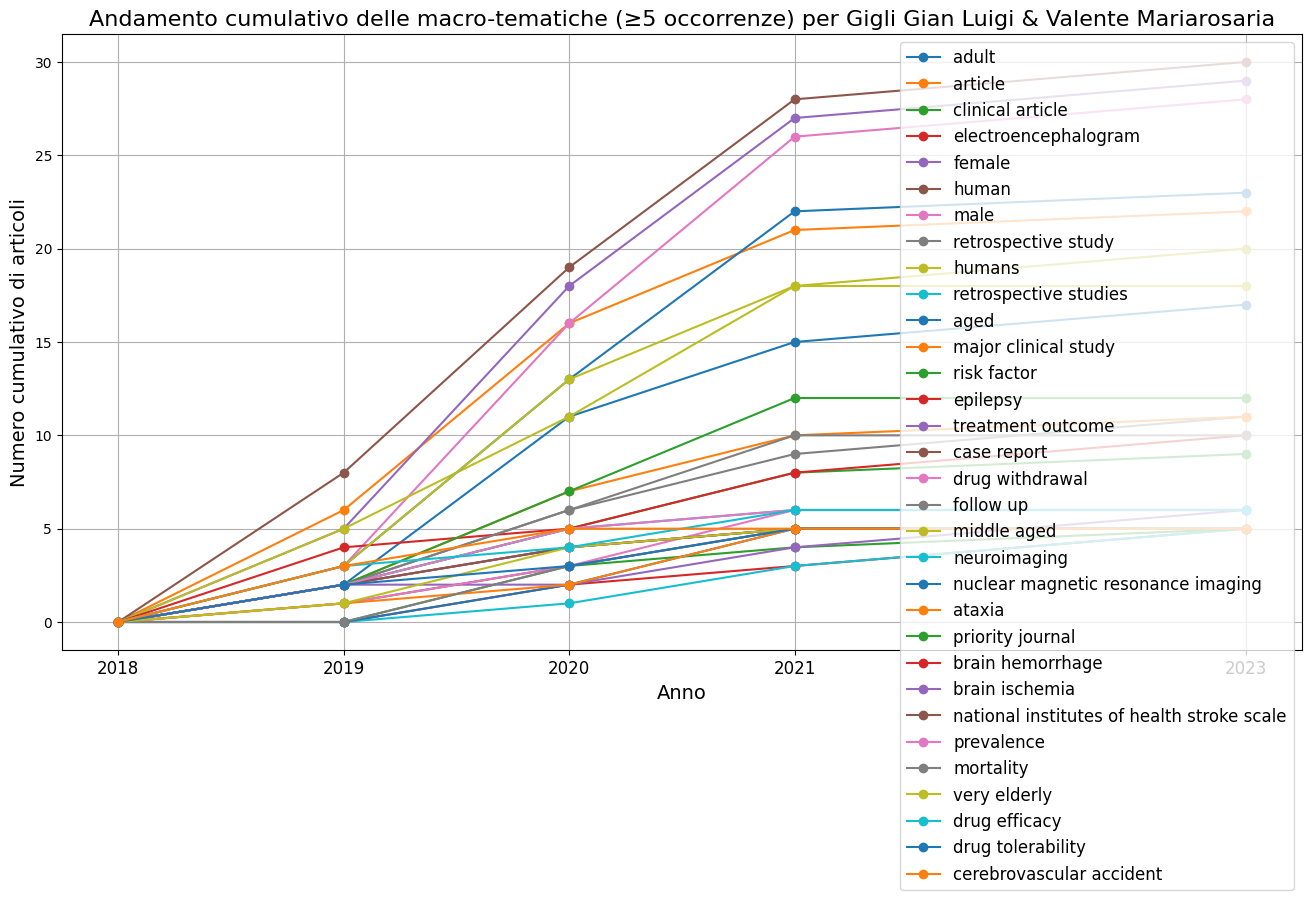

In [195]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# -------------------------
# Prendi la prima coppia da pairs_df
# -------------------------
if not pairs_df.empty:
    first_pair = pairs_df.iloc[0][["Author1","Author2"]].tolist()
else:
    print("pairs_df vuoto!")
    first_pair = []

target_authors = set(first_pair)
print("Autori selezionati:", target_authors)

# -------------------------
# Prepara index_keywords_list se non esiste
# -------------------------
if "index_kw_list" not in df.columns:
    def split_index_kw(x):
        if pd.isna(x):
            return []
        return [k.strip().lower() for k in str(x).split(";") if k.strip()]
    df["index_kw_list"] = df["Index Keywords"].apply(split_index_kw)

# -------------------------
# Filtra articoli contenenti entrambi gli autori
# -------------------------
mask = df["authors_list"].apply(lambda lst: target_authors.issubset(set(lst)))
df_pair = df.loc[mask]

if df_pair.empty:
    print("Nessun articolo trovato per questa coppia.")
else:
    # -------------------------
    # Conta tutte le keyword
    # -------------------------
    all_kw = [kw for kws in df_pair["index_kw_list"] for kw in kws]
    kw_counts = Counter(all_kw)

    # Applica soglia minima: almeno 5 occorrenze
    min_occurrences = 5
    top_keywords = [kw for kw, cnt in kw_counts.items() if cnt >= min_occurrences]

    if not top_keywords:
        print(f"Nessuna keyword compare almeno {min_occurrences} volte.")
    else:
        # -------------------------
        # Crea struttura anno -> keyword -> count
        # -------------------------
        data = {}
        for anno, df_anno in df_pair.groupby("Year"):
            if pd.isna(anno):
                continue
            counts = Counter([kw for kws in df_anno["index_kw_list"] for kw in kws])
            data[int(anno)] = {kw: counts.get(kw, 0) for kw in top_keywords}

        df_trend = pd.DataFrame(data).T.sort_index()

        # -------------------------
        # Aggiungi 2018 se mancante
        # -------------------------
        if 2018 not in df_trend.index:
            df_trend.loc[2018] = {kw: 0 for kw in top_keywords}
            df_trend = df_trend.sort_index()

        # -------------------------
        # Cumulativo anno per anno
        # -------------------------
        df_trend_cumsum = df_trend.cumsum()

        # -------------------------
        # Grafico
        # -------------------------
        plt.figure(figsize=(16,8))  # aumento delle dimensioni
        for kw in top_keywords:
            plt.plot(df_trend_cumsum.index, df_trend_cumsum[kw], marker='o', label=kw)

        plt.title(f"Andamento cumulativo delle macro-tematiche (≥{min_occurrences} occorrenze) per {first_pair[0]} & {first_pair[1]}", fontsize=16)
        plt.xlabel("Anno", fontsize=14)
        plt.ylabel("Numero cumulativo di articoli", fontsize=14)
        plt.grid(True)
        plt.legend(fontsize=12)

        # Imposta gli anni consecutivi come xticks
        plt.xticks(sorted(df_trend_cumsum.index), fontsize=12)

        plt.show()


Autori selezionati: {'Valente Mariarosaria', 'Gigli Gian Luigi'}


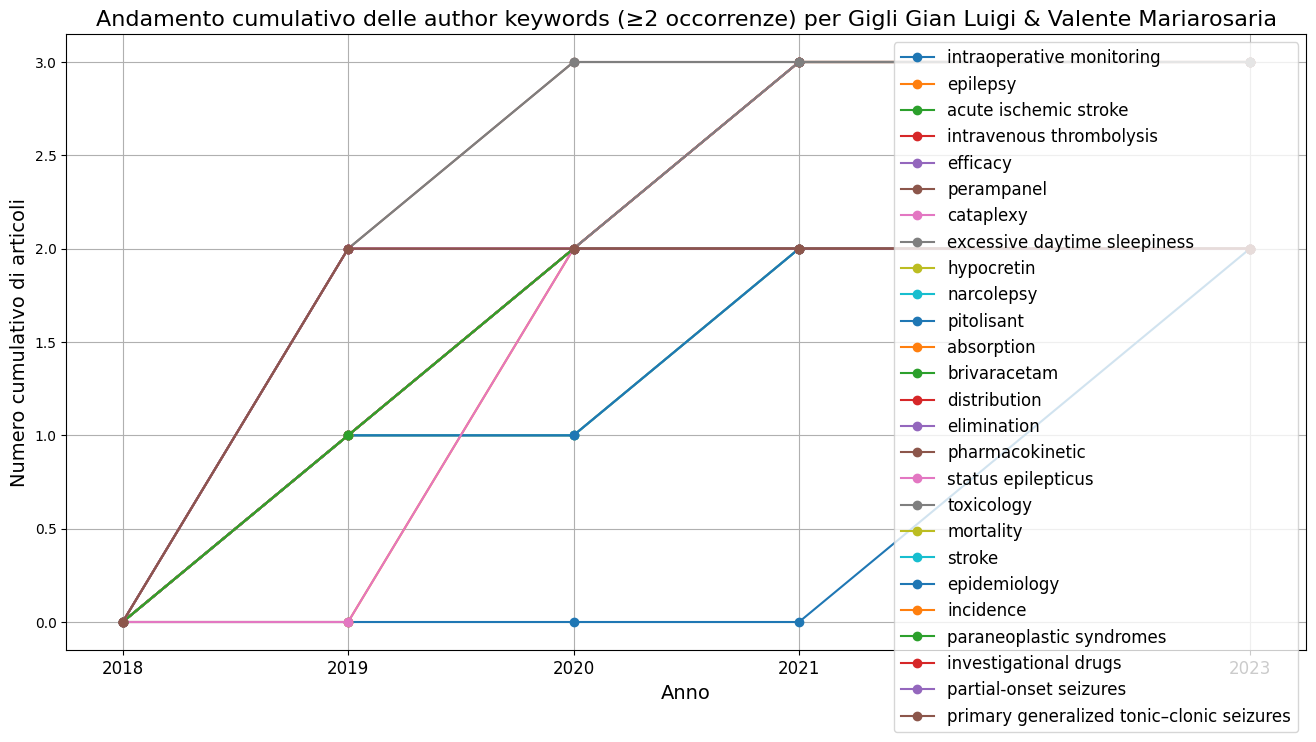

In [196]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# -------------------------
# Prendi la prima coppia da pairs_df
# -------------------------
if not pairs_df.empty:
    first_pair = pairs_df.iloc[0][["Author1","Author2"]].tolist()
else:
    print("pairs_df vuoto!")
    first_pair = []

target_authors = set(first_pair)
print("Autori selezionati:", target_authors)

# -------------------------
# Prepara author_keywords_list se non esiste
# -------------------------
if "author_kw_list" not in df.columns:
    def split_author_kw(x):
        if pd.isna(x):
            return []
        return [k.strip().lower() for k in str(x).split(";") if k.strip()]
    df["author_kw_list"] = df["Author Keywords"].apply(split_author_kw)

# -------------------------
# Filtra articoli contenenti entrambi gli autori
# -------------------------
mask = df["authors_list"].apply(lambda lst: target_authors.issubset(set(lst)))
df_pair = df.loc[mask]

if df_pair.empty:
    print("Nessun articolo trovato per questa coppia.")
else:
    # -------------------------
    # Conta tutte le author keywords
    # -------------------------
    all_kw = [kw for kws in df_pair["author_kw_list"] for kw in kws]
    kw_counts = Counter(all_kw)

    # Applica soglia minima: almeno 3 occorrenze
    min_occurrences = 2
    top_keywords = [kw for kw, cnt in kw_counts.items() if cnt >= min_occurrences]

    if not top_keywords:
        print(f"Nessuna author keyword compare almeno {min_occurrences} volte.")
    else:
        # -------------------------
        # Crea struttura anno -> keyword -> count
        # -------------------------
        data = {}
        for anno, df_anno in df_pair.groupby("Year"):
            if pd.isna(anno):
                continue
            counts = Counter([kw for kws in df_anno["author_kw_list"] for kw in kws])
            data[int(anno)] = {kw: counts.get(kw, 0) for kw in top_keywords}

        df_trend = pd.DataFrame(data).T.sort_index()

        # -------------------------
        # Aggiungi 2018 se mancante
        # -------------------------
        if 2018 not in df_trend.index:
            df_trend.loc[2018] = {kw: 0 for kw in top_keywords}
            df_trend = df_trend.sort_index()

        # -------------------------
        # Cumulativo anno per anno
        # -------------------------
        df_trend_cumsum = df_trend.cumsum()

        # -------------------------
        # Grafico
        # -------------------------
        plt.figure(figsize=(16,8))  # dimensione più grande
        for kw in top_keywords:
            plt.plot(df_trend_cumsum.index, df_trend_cumsum[kw], marker='o', label=kw)

        plt.title(f"Andamento cumulativo delle author keywords (≥{min_occurrences} occorrenze) per {first_pair[0]} & {first_pair[1]}", fontsize=16)
        plt.xlabel("Anno", fontsize=14)
        plt.ylabel("Numero cumulativo di articoli", fontsize=14)
        plt.grid(True)
        plt.legend(fontsize=12)

        # Imposta gli anni consecutivi come xticks
        plt.xticks(sorted(df_trend_cumsum.index), fontsize=12)

        plt.show()


In [197]:
from pyvis.network import Network
import pandas as pd

df = pd.read_csv("nuovo_dataset.csv")

area_map = {
    "Lecture Notes in Computer Science": "Computer Science",
    "CEUR Workshop Proceedings": "Computer Science",
    "Theory and Practice of Logic Programming": "Computer Science",
    "Proceedings of Science": "Computer Science",
    "Journal of Physics: Conference Series": "Physics",
    "Challenges in Physics Education": "Physics",
    "Journal of Neurology": "Medicine",
    "Journal of Clinical Medicine": "Medicine",
    "Expert Opinion on Pharmacotherapy": "Pharmacology",
    "Expert Opinion on Drug Metabolism and Toxicology": "Pharmacology"
}

df["Area"] = df["Source title"].map(area_map).fillna("Other")

edges = (
    df.groupby(["Area", "Source title"])
    .size()
    .reset_index(name="weight")
)

net = Network(height="650px", width="100%", bgcolor="white")

for area in edges["Area"].unique():
    net.add_node(area, label=area, shape="ellipse", size=35)

for _, row in edges.iterrows():
    net.add_node(row["Source title"], label=row["Source title"], shape="box")
    net.add_edge(row["Area"], row["Source title"], value=row["weight"])

# 👇 usa QUESTO
net.save_graph("interdisciplinarita.html")


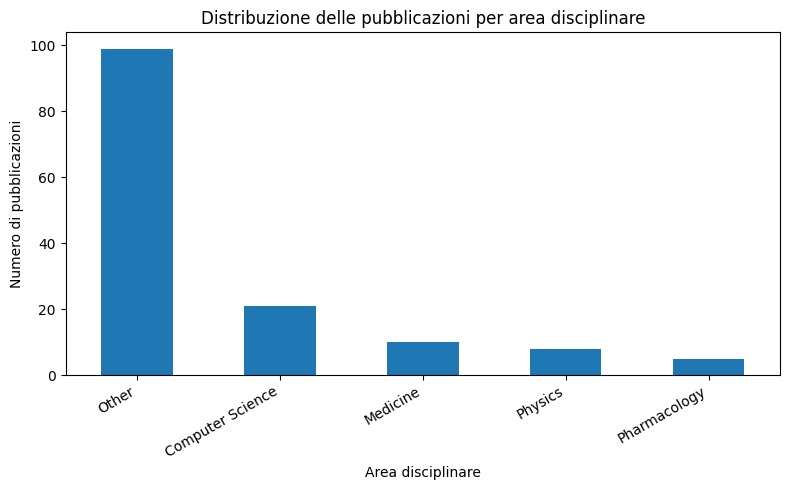

In [198]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("nuovo_dataset.csv")

area_map = {
    "Lecture Notes in Computer Science": "Computer Science",
    "CEUR Workshop Proceedings": "Computer Science",
    "Theory and Practice of Logic Programming": "Computer Science",
    "Proceedings of Science": "Computer Science",
    "Journal of Physics: Conference Series": "Physics",
    "Challenges in Physics Education": "Physics",
    "Journal of Neurology": "Medicine",
    "Journal of Clinical Medicine": "Medicine",
    "Expert Opinion on Pharmacotherapy": "Pharmacology",
    "Expert Opinion on Drug Metabolism and Toxicology": "Pharmacology"
}

df["Area"] = df["Source title"].map(area_map).fillna("Other")

area_counts = df["Area"].value_counts()

plt.figure(figsize=(8, 5))
area_counts.plot(kind="bar")
plt.xlabel("Area disciplinare")
plt.ylabel("Numero di pubblicazioni")
plt.title("Distribuzione delle pubblicazioni per area disciplinare")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [199]:
def infer_area(source):
    s = source.lower()

    if any(k in s for k in ["computer", "informatics", "logic", "workshop", "proceedings"]):
        return "Computer Science"

    if any(k in s for k in ["physics", "physical"]):
        return "Physics"

    if any(k in s for k in ["neurology", "clinical", "medicine", "medical"]):
        return "Medicine"

    if any(k in s for k in ["pharma", "drug", "toxicology", "metabolism"]):
        return "Pharmacology"

    return "Other"


In [200]:
from pyvis.network import Network
import pandas as pd

df = pd.read_csv("nuovo_dataset.csv")

df["Area"] = df["Source title"].fillna("").apply(infer_area)

edges = (
    df.groupby(["Area", "Source title"])
    .size()
    .reset_index(name="weight")
)

net = Network(
    height="650px",
    width="100%",
    bgcolor="white",
    font_color="black"
)

# nodi area
for area in edges["Area"].unique():
    net.add_node(
        area,
        label=area,
        shape="ellipse",
        size=35
    )

# nodi source + archi
for _, row in edges.iterrows():
    net.add_node(
        row["Source title"],
        label=row["Source title"],
        shape="box"
    )
    net.add_edge(
        row["Area"],
        row["Source title"],
        value=row["weight"]
    )

net.save_graph("interdisciplinarita_grafo.html")


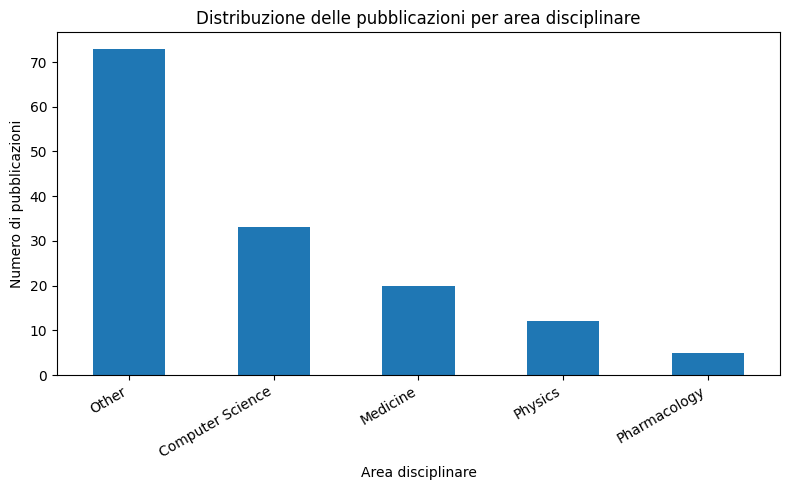

In [201]:
import matplotlib.pyplot as plt

area_counts = df["Area"].value_counts()

plt.figure(figsize=(8, 5))
area_counts.plot(kind="bar")
plt.xlabel("Area disciplinare")
plt.ylabel("Numero di pubblicazioni")
plt.title("Distribuzione delle pubblicazioni per area disciplinare")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [202]:
import pandas as pd
from pyvis.network import Network

# Caricamento dati
df = pd.read_csv("nuovo_dataset.csv")

def infer_area(title):
    title_low = str(title).lower()
    # Logica Math
    if any(k in title_low for k in ["math", "algebra", "logic", "discrete", "geometry", "analis", "matemat"]):
        return "Math"
    # Logica Science Computing (estesa per svuotare "Other")
    if any(k in title_low for k in ["computer", "algorithm", "informatic", "computing", "systems", 
                                    "intelligence", "ai", "software", "data", "cyber", "heuristics", 
                                    "automated planning", "acm", "ieee", "multimedia", "ceur", 
                                    "signal processing", "networks"]):
        return "Science computing"
    # Logica Medicine/Health
    if any(k in title_low for k in ["medicine", "neuro", "clinical", "drug", "health", "pharmac", 
                                    "genet", "cancer", "bio", "oncology", "epilepsy", "sleep", 
                                    "seizure", "cerebellum", "sclerosis", "thrombosis"]):
        return "Medicine/Health"
    # Logica Physics & Hard Sciences
    if any(k in title_low for k in ["physic", "nuclear", "chemical", "chemistry", "nanoscale", "molecule"]):
        return "Physics/Science"
    # Logica Engineering
    if any(k in title_low for k in ["engineering", "mechanical", "electrical", "transportation", "manufacturing"]):
        return "Engineering"
    
    return "Other"

# Applichiamo la classificazione
df["Area"] = df["Source title"].fillna("").apply(infer_area)

# Raggruppamento per pesi
edges = df.groupby(["Area", "Source title"]).size().reset_index(name="weight")

net = Network(height="750px", width="100%", bgcolor="white", font_color="black")

# Colori per macro-aree
colors = {
    "Math": "#ff7f0e", 
    "Science computing": "#1f77b4", 
    "Medicine/Health": "#d62728",
    "Physics/Science": "#2ca02c",
    "Engineering": "#9467bd",
    "Other": "#7f7f7f"
}

# 1. Aggiunta nodi Area
for area in edges["Area"].unique():
    net.add_node(area, label=area, shape="ellipse", size=40, color=colors.get(area, "#97c2fc"))

# 2. Aggiunta nodi Source + Archi verso le aree
for _, row in edges.iterrows():
    net.add_node(row["Source title"], label=row["Source title"], shape="box", size=15, color="#eeeeee")
    net.add_edge(row["Area"], row["Source title"], value=row["weight"], color=colors.get(row["Area"], "#848484"))

# 3. COLLEGAMENTO MANUALE tra Math e Science computing
net.add_edge("Math", "Science computing", weight=10, label="Interdisciplinary Connection", 
             color="black", width=4, dashes=True)

# Opzioni di layout per una migliore leggibilità
net.set_options("""
var options = {
  "physics": {
    "forceAtlas2Based": { "gravitationalConstant": -100, "springLength": 100 },
    "solver": "forceAtlas2Based",
    "stabilization": { "iterations": 100 }
  }
}
""")

net.save_graph("interdisciplinarita_grafo_migliorato.html")

In [203]:
import pandas as pd
from pyvis.network import Network

# 1. Caricamento del dataset
try:
    df = pd.read_csv("nuovo_dataset.csv")
except FileNotFoundError:
    print("Errore: Assicurati che il file 'nuovo_dataset.csv' sia nella stessa cartella dello script.")
    exit()

# 2. Funzione di classificazione avanzata (Riduzione "Other" e sviluppo "Punto 1")
def infer_area(title):
    t = str(title).lower()
    
    # Parole chiave per categoria
    kw_math = ["math", "algebra", "logic", "discrete", "geometry", "analis", "matemat", "combinatorics", "numerical"]
    kw_computing = ["computer", "algorithm", "informatic", "computing", "systems", "intelligence", "ai", 
                    "software", "data", "cyber", "heuristics", "acm", "ieee", "programming", "vision", "signal"]
    kw_med = ["medicine", "neuro", "clinical", "drug", "health", "pharmac", "genet", "cancer", "bio", 
              "oncology", "epilepsy", "sleep", "cerebellum", "sclerosis", "thrombosis", "physiolog"]
    
    # LOGICA "PUNTO 1": Intersezione Neuro-Informatica (Il Ponte)
    is_medical = any(k in t for k in kw_med)
    is_comp = any(k in t for k in kw_computing)
    
    if is_medical and is_comp:
        return "Neuro-Computing (Ponte)"
    
    # Classificazione standard
    if any(k in t for k in kw_math):
        return "Math"
    if is_comp:
        return "Science computing"
    if is_medical:
        return "Medicine/Health"
    if any(k in t for k in ["physic", "nuclear", "chemical", "nanoscale", "molecule", "science"]):
        return "Pure Sciences"
    if any(k in t for k in ["engineering", "mechanical", "electrical", "transportation", "manufacturing"]):
        return "Engineering"
    
    return "Other"

# Applicazione della logica
df["Area"] = df["Source title"].fillna("").apply(infer_area)

# 3. Preparazione dei dati per il grafo (Raggruppamento)
edges_data = df.groupby(["Area", "Source title"]).size().reset_index(name="weight")

# 4. Inizializzazione Rete Pyvis
net = Network(height="800px", width="100%", bgcolor="#ffffff", font_color="black", heading="Grafo dell'Interdisciplinarità")

# Definizione colori per macro-aree
color_palette = {
    "Math": "#FFD700",                # Oro
    "Science computing": "#1E90FF",    # Blu
    "Neuro-Computing (Ponte)": "#FF4500", # Arancio/Rosso (Evidenziato)
    "Medicine/Health": "#32CD32",      # Verde
    "Pure Sciences": "#BA55D3",        # Viola
    "Engineering": "#808080",          # Grigio
    "Other": "#C0C0C0"                 # Argento
}

# 5. Aggiunta dei nodi Macro-Aree (Ellissi grandi)
for area in edges_data["Area"].unique():
    net.add_node(
        area, 
        label=area, 
        shape="ellipse", 
        size=45, 
        color=color_palette.get(area, "#97c2fc"),
        font={'size': 25, 'face': 'Arial', 'weight': 'bold'}
    )

# 6. Aggiunta dei nodi Riviste (Box piccoli) e archi
for _, row in edges_data.iterrows():
    source = row["Source title"]
    area = row["Area"]
    weight = row["weight"]
    
    # Nodo Rivista
    net.add_node(
        source, 
        label=source, 
        shape="box", 
        size=15, 
        color="#eeeeee",
        font={'size': 12}
    )
    
    # Arco Area -> Rivista
    net.add_edge(
        area, 
        source, 
        value=weight, 
        title=f"Occorrenze: {weight}",
        color=color_palette.get(area, "#848484"),
        alpha=0.6
    )

# 7. COLLEGAMENTI INTERDISCIPLINARI (I "Ponti")
# Collegamento richiesto: Math -> Science Computing
net.add_edge(
    "Math", "Science computing", 
    label="Fondamenti Matematici", 
    weight=15, 
    color="#000000", 
    width=5, 
    dashes=True
)

# Collegamento Punto 1: Science Computing -> Neuro-Computing
net.add_edge(
    "Science computing", "Neuro-Computing (Ponte)", 
    label="Algoritmi Neurali", 
    weight=10, 
    color="#FF4500", 
    width=3
)

# 8. Configurazione Fisica per un layout pulito
net.set_options("""
var options = {
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -150,
      "centralGravity": 0.005,
      "springLength": 150,
      "springStrength": 0.05
    },
    "solver": "forceAtlas2Based",
    "stabilization": { "iterations": 150 }
  },
  "interaction": {
    "hover": true,
    "navigationButtons": true
  }
}
""")

# 9. Salvataggio e generazione del file
net.save_graph("grafo_interdisciplinare_finale.html")
print("Grafo generato con successo: apri 'grafo_interdisciplinare_finale.html' nel tuo browser.")

Grafo generato con successo: apri 'grafo_interdisciplinare_finale.html' nel tuo browser.


In [204]:
import pandas as pd
from pyvis.network import Network

# 1. Caricamento dati
df = pd.read_csv("nuovo_dataset.csv")

# 2. Definizione dei Dizionari di Keywords per Macro-Area
# Puoi aggiungere o modificare queste parole per affinare la precisione
categories_map = {
    "Math": [
        "graph theory", "combinatorics", "optimization", "algebra", "logic", 
        "discrete mathematics", "topology", "geometry", "calculus", "numerical analysis"
    ],
    "Science computing": [
        "machine learning", "artificial intelligence", "algorithms", "neural networks", 
        "deep learning", "software", "data mining", "computer vision", "heuristics",
        "cybersecurity", "big data", "cloud computing", "iot"
    ],
    "Medicine/Health": [
        "neurology", "epilepsy", "clinical", "biomedical", "brain", "genetics", 
        "pharmacology", "therapy", "oncology", "patient", "eeg", "mri", "healthcare"
    ],
    "Physics/Engineering": [
        "physics", "mechanics", "thermodynamics", "electronics", "control systems", 
        "robotics", "nanotechnology", "nuclear", "material science", "fluid dynamics"
    ]
}

def classify_by_keywords(row):
    # Uniamo keywords degli autori e titoli per sicurezza
    keywords = str(row["Author Keywords"]).lower()
    title = str(row["Source title"]).lower()
    content = keywords + " " + title
    
    found_areas = []
    
    for area, keywords_list in categories_map.items():
        if any(k in content for k in keywords_list):
            found_areas.append(area)
    
    # Logica "Punto 1": Se troviamo sia elementi medici che informatici
    if "Medicine/Health" in found_areas and "Science computing" in found_areas:
        return ["Neuro-Computing (Ponte)"]
    
    return found_areas if found_areas else ["Other"]

# 3. Trasformazione del Dataset
# Esplodiamo le righe: se un articolo ha 2 aree, creiamo 2 connessioni nel grafo
df["Areas"] = df.apply(classify_by_keywords, axis=1)
df_exploded = df.explode("Areas")

# 4. Creazione del Grafo
net = Network(height="800px", width="100%", bgcolor="white", font_color="black")

colors = {
    "Math": "#FFD700",
    "Science computing": "#1E90FF",
    "Neuro-Computing (Ponte)": "#FF4500",
    "Medicine/Health": "#32CD32",
    "Physics/Engineering": "#BA55D3",
    "Other": "#C0C0C0"
}

# Aggiunta nodi Macro-Aree
for area, color in colors.items():
    net.add_node(area, label=area, shape="ellipse", size=50, color=color, font={'size': 30})

# Aggiunta nodi Journal e Archi
edges = df_exploded.groupby(["Areas", "Source title"]).size().reset_index(name="weight")

for _, row in edges.iterrows():
    # Nodo Journal (se non esiste già)
    net.add_node(row["Source title"], label=row["Source title"], shape="box", size=15, color="#f0f0f0")
    
    # Arco verso la macro-area basata sulle keywords
    net.add_edge(
        row["Areas"], 
        row["Source title"], 
        value=row["weight"], 
        color=colors.get(row["Areas"], "#848484")
    )

# Collegamento manuale richiesto Math <-> Science Computing
net.add_edge("Math", "Science computing", label="Interdisciplinary", color="black", width=3, dashes=True)

# Opzioni di layout
net.set_options("""
var options = {
  "physics": {
    "forceAtlas2Based": { "gravitationalConstant": -150, "springLength": 120 },
    "solver": "forceAtlas2Based",
    "stabilization": { "iterations": 150 }
  }
}
""")

net.save_graph("grafo_keywords_precision.html")
print("Grafo generato con successo basandosi sulle Author Keywords.")

Grafo generato con successo basandosi sulle Author Keywords.


In [205]:
import pandas as pd
from pyvis.network import Network

# 1. Caricamento dati
df = pd.read_csv("nuovo_dataset.csv")

# 2. Espansione del Dizionario (Più termini = Meno "Other")
categories_map = {
    "Math": [
        "math", "algebra", "logic", "discrete", "geometry", "analis", "matemat", 
        "combinatorics", "graph theory", "set theory", "formal proofs", "optimization",
        "calculus", "numerical", "complexity"
    ],
    "Science computing": [
        "computer", "algorithm", "informatic", "computing", "systems", "intelligence", 
        "ai", "software", "data", "cyber", "heuristics", "ceur", "acm", "ieee", 
        "machine learning", "deep learning", "neural net", "signal processing", 
        "vision", "image", "cloud", "iot", "programming", "simulation"
    ],
    "Medicine/Health": [
        "medicine", "neuro", "clinical", "drug", "health", "pharmac", "genet", 
        "cancer", "bio", "oncology", "epilepsy", "sleep", "seizure", "cerebellum", 
        "sclerosis", "thrombosis", "brain", "patient", "therapy", "medical"
    ],
    "Physics/Hard Science": [
        "physic", "nuclear", "chemical", "chemistry", "nanoscale", "molecule", 
        "material", "energy", "atoms", "mechanics", "astronomy", "scientific"
    ],
    "Engineering": [
        "engineering", "mechanical", "electrical", "transportation", "manufacturing", 
        "robotics", "control", "automation", "electronics", "sensors"
    ]
}

def classify_row(row):
    # Uniamo tutte le fonti di testo disponibili per ogni riga
    text_sources = [
        str(row.get("Author Keywords", "")),
        str(row.get("Index Keywords", "")),
        str(row.get("Source title", ""))
    ]
    content = " ".join(text_sources).lower()
    
    found_areas = []
    
    # Controllo delle categorie
    for area, keywords in categories_map.items():
        if any(k in content for k in keywords):
            found_areas.append(area)
    
    # Logica Speciale: Neuro-Computing (Punto 1)
    if "Medicine/Health" in found_areas and "Science computing" in found_areas:
        return ["Neuro-Computing (Ponte)"]
    
    # Se non trova nulla, restituisce "Other"
    return found_areas if found_areas else ["Other"]

# 3. Applicazione e preparazione dati
df["Areas"] = df.apply(classify_row, axis=1)
df_exploded = df.explode("Areas")

# 4. Creazione Grafo
net = Network(height="800px", width="100%", bgcolor="#ffffff", font_color="black")

# Palette colori
colors = {
    "Math": "#FFD700",
    "Science computing": "#1E90FF",
    "Neuro-Computing (Ponte)": "#FF4500",
    "Medicine/Health": "#32CD32",
    "Physics/Hard Science": "#BA55D3",
    "Engineering": "#FF69B4",
    "Other": "#A9A9A9" # Grigio per i pochi rimasti
}

# Aggiunta nodi Area
for area, color in colors.items():
    net.add_node(area, label=area, shape="ellipse", size=50, color=color, font={'size': 30, 'weight': 'bold'})

# Raggruppamento per archi
edges = df_exploded.groupby(["Areas", "Source title"]).size().reset_index(name="weight")

# Aggiunta nodi Riviste e Archi
for _, row in edges.iterrows():
    net.add_node(row["Source title"], label=row["Source title"], shape="box", size=15, color="#f0f0f0")
    net.add_edge(row["Areas"], row["Source title"], value=row["weight"], color=colors.get(row["Areas"], "#848484"))

# Collegamento manuale richiesto: Math <-> Computing
net.add_edge("Math", "Science computing", label="Interdisciplinary Link", color="#000000", width=4, dashes=True)

# Opzioni di layout
net.set_options("""
var options = {
  "physics": {
    "forceAtlas2Based": { "gravitationalConstant": -120, "springLength": 150 },
    "solver": "forceAtlas2Based"
  }
}
""")

net.save_graph("grafo_no_other.html")
print("Grafo salvato. La sezione 'Other' dovrebbe essere ora minima.")

Grafo salvato. La sezione 'Other' dovrebbe essere ora minima.


In [206]:
import pandas as pd
from pyvis.network import Network

# 1. Caricamento del dataset
df = pd.read_csv("nuovo_dataset.csv")

# 2. Definizione Macro-Aree basata esclusivamente su Index Keywords
# Usiamo i nomi delle aree come "filtri" per scansionare la colonna Index Keywords
def classify_by_index(index_text):
    text = str(index_text).lower()
    if text == "nan" or not text.strip():
        return ["Other"]
    
    found_areas = []
    
    # Mappatura diretta: cerchiamo la radice dell'area nelle Index Keywords
    mapping = {
        "Math": ["math", "algebra", "logic", "combinatorics", "graph theory", "geometry"],
        "Science computing": ["computer", "algorithm", "intelligence", "data", "software", "computing"],
        "Medicine/Health": ["medicine", "neuro", "clinical", "biomedical", "health", "pharmac"],
        "Physics": ["physics", "nuclear", "energy", "matter"],
        "Engineering": ["engineering", "mechanical", "electrical", "control", "systems"]
    }
    
    for area, roots in mapping.items():
        if any(root in text for root in roots):
            found_areas.append(area)
            
    # Punto 1: Se un articolo ha sia termini "neuro/med" che "comp/alg" nelle Index Keywords
    if "Medicine/Health" in found_areas and "Science computing" in found_areas:
        return ["Neuro-Computing (Ponte)"]
        
    return found_areas if found_areas else ["Other"]

# 3. Trasformazione: Ogni riga può appartenere a più aree (Interdisciplinarità)
df["Areas"] = df["Index Keywords"].apply(classify_by_index)
df_exploded = df.explode("Areas")

# 4. Creazione del Grafo con Pyvis
net = Network(height="750px", width="100%", bgcolor="white", font_color="black")

# Colori assegnati alle macro-aree
colors = {
    "Math": "#FFD700",
    "Science computing": "#1E90FF",
    "Neuro-Computing (Ponte)": "#FF4500",
    "Medicine/Health": "#32CD32",
    "Physics": "#BA55D3",
    "Engineering": "#FF69B4",
    "Other": "#C0C0C0"
}

# Aggiunta nodi Macro-Aree
for area, color in colors.items():
    net.add_node(area, label=area, shape="ellipse", size=50, color=color, font={'size': 25, 'weight': 'bold'})

# Raggruppamento per generare i pesi degli archi
# (Quante volte un Journal è indicizzato in quella macro-area?)
edges = df_exploded.groupby(["Areas", "Source title"]).size().reset_index(name="weight")

for _, row in edges.iterrows():
    # Nodo Rivista
    net.add_node(row["Source title"], label=row["Source title"], shape="box", size=15, color="#f0f0f0")
    # Arco dalla Macro-Area alla Rivista
    net.add_edge(
        row["Areas"], 
        row["Source title"], 
        value=row["weight"], 
        color=colors.get(row["Areas"], "#848484"),
        title=f"Basato su Index Keywords: {row['weight']} occorrenze"
    )

# Collegamento tra Math e Science Computing (richiesto)
net.add_edge("Math", "Science computing", label="Fondamenti", color="black", width=3, dashes=True)

# 5. Configurazione Layout
net.set_options("""
var options = {
  "physics": {
    "forceAtlas2Based": { "gravitationalConstant": -100, "springLength": 150 },
    "solver": "forceAtlas2Based",
    "stabilization": { "iterations": 100 }
  }
}
""")

net.save_graph("grafo_index_keywords.html")
print("Grafo generato utilizzando esclusivamente la colonna 'Index Keywords'.")

Grafo generato utilizzando esclusivamente la colonna 'Index Keywords'.


In [207]:
#ODICE LISTA ESTERE VS ITALIANE: 
import pandas as pd
import re

# ----------------------------------
# 1. CARICAMENTO
# ----------------------------------

df = pd.read_csv("nuovo_dataset.csv")

# Assicurati che ci sia una colonna Affiliations
df = df.dropna(subset=["Affiliations"])

# Separa autori e affiliazioni in strutture
# (dipende da come sono formattate: qui assumiamo delimitate da ';')
df["AffiliationsList"] = df["Affiliations"].str.split(";")

# ----------------------------------
# 2. TROVA PAPER CON UDINE
# ----------------------------------

def is_udine_aff(aff):
    return bool(re.search(r"\bUdine\b", aff, flags=re.IGNORECASE))

# tutti i paper con almeno una affiliazione Udine
df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine_aff(a) for a in affs))]

# ----------------------------------
# 3. ESTRAI TUTTE LE COLLABORAZIONI
# ----------------------------------

collab_affiliations = []

for idx, row in df_udine.iterrows():
    for aff in row["AffiliationsList"]:
        aff_clean = aff.strip()
        if not is_udine_aff(aff_clean):
            collab_affiliations.append(aff_clean)

# ----------------------------------
# 4. CLASSIFICA ITALIANE VS ESTERE
# ----------------------------------

def classify_affiliation(aff):
    aff = aff.lower()
    if "italy" in aff or aff.endswith("italy"):
        return "Italian"
    else:
        return "Foreign"

collab_df = pd.DataFrame({
    "Affiliation": collab_affiliations
})

collab_df["Type"] = collab_df["Affiliation"].apply(classify_affiliation)

# ----------------------------------
# 5. RISULTATI: STATISTICHE
# ----------------------------------

italian_collabs = collab_df[collab_df["Type"] == "Italian"]
foreign_collabs = collab_df[collab_df["Type"] == "Foreign"]

print("Numero collaborazioni italiane:", italian_collabs.shape[0])
print("Numero collaborazioni estere:", foreign_collabs.shape[0])

print("\nTop 10 istituzioni italiane:")
print(italian_collabs["Affiliation"].value_counts().head(10))

print("\nTop 10 istituzioni estere:")
print(foreign_collabs["Affiliation"].value_counts().head(10))

Numero collaborazioni italiane: 93
Numero collaborazioni estere: 185

Top 10 istituzioni italiane:
Affiliation
Università degli Studi di Padova, Padua, PD, Italy                                                           7
Istituto Nazionale di Fisica Nucleare, Sezione di Trieste, Trieste, TS, Italy                                5
Department of Diagnostic Imaging, Fondazione Poliambulanza Istituto Ospedaliero, Brescia, Italy              4
Università degli Studi di Trieste, Trieste, TS, Italy                                                        3
Istituto Nazionale di Biostrutture e Biosistemi, Rome, RM, Italy                                             3
Department of Neurological Sciences, Università Vita-Salute San Raffaele, Milan, MI, Italy                   3
Department of Medical Sciences and Public Health, Università degli Studi di Cagliari, Cagliari, CA, Italy    3
Politecnico di Milano, Milan, MI, Italy                                                                      3
T

In [208]:
import pandas as pd
import networkx as nx
import re
import plotly.graph_objects as go

# =====================================
# 1. CARICAMENTO E PULIZIA
# =====================================
df = pd.read_csv("nuovo_dataset.csv")
df = df.dropna(subset=["Affiliations"])
df["AffiliationsList"] = df["Affiliations"].str.split(";")

# 2. IDENTIFICAZIONE UDINE
def is_udine(aff):
    return bool(re.search(r"\bUdine\b", str(aff), re.IGNORECASE))

df_udine = df[df["AffiliationsList"].apply(lambda affs: any(is_udine(a) for a in affs))]

# 3. ESTRAZIONE COLLABORAZIONI
collaborations = []
for _, row in df_udine.iterrows():
    for aff in row["AffiliationsList"]:
        aff = aff.strip()
        if not is_udine(aff):
            collaborations.append(aff)

# 4. CLASSIFICAZIONE E CONTEGGIO
def classify_affiliation(aff):
    return "Italian" if "italy" in aff.lower() else "Foreign"

collab_df = pd.DataFrame({"Affiliation": collaborations})
collab_df["Type"] = collab_df["Affiliation"].apply(classify_affiliation)
collab_counts = collab_df.groupby(["Affiliation", "Type"]).size().reset_index(name="weight")
collab_counts = collab_counts[collab_counts["weight"] >= 2]

# =====================================
# 5. COSTRUZIONE GRAFO
# =====================================
G = nx.Graph()
G.add_node("University of Udine", role="udine")
for _, row in collab_counts.iterrows():
    G.add_node(row["Affiliation"], role=row["Type"], weight=row["weight"])
    G.add_edge("University of Udine", row["Affiliation"], weight=row["weight"])

pos = nx.spring_layout(G, seed=42)

# =====================================
# 6. TRACCE PLOTLY
# =====================================
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

# Traccia Collegamento (Legenda Linea)
edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1, color='#888'),
    hoverinfo='none',
    mode='lines',
    showlegend=True,
    name='Collaborazioni'
)

node_x, node_y, node_text, node_color, node_size = [], [], [], [], []
for node, data in G.nodes(data=True):
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"{node}<br>Collaborazioni: {data.get('weight', 0)}")
    role = data["role"]
    node_color.append('red' if role=="udine" else 'skyblue' if role=="Italian" else 'orange')
    size = 25 if role=="udine" else 10 + 5 * data.get('weight', 1)
    node_size.append(size)

# Traccia Nodi (Senza duplicato in legenda)
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    text=node_text,
    hoverinfo='text',
    marker=dict(color=node_color, size=node_size, line_width=1.5),
    showlegend=False
)

# Legenda Personalizzata
legend_traces = [
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=12, color='red'), name='Udine'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=12, color='skyblue'), name='Italia'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=12, color='orange'), name='Estero')
]

# =====================================
# 7. VISUALIZZAZIONE GRAFO
# =====================================
fig = go.Figure(data=[edge_trace, node_trace] + legend_traces,
                layout=go.Layout(
                    title="Collaborazioni dell’Università di Udine (Italia vs Estero)",
                    title_x=0.5,
                    showlegend=True,
                    legend=dict(x=1.02, y=0.95, bordercolor="Black", borderwidth=1),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    margin=dict(l=50, r=200, t=80, b=50),
                    hovermode='closest'
                )
)

fig.show()

# =====================================
# 8. TABELLA TOP 3 (TUTTO A SINISTRA)
# =====================================
top_italy = collab_counts[collab_counts["Type"]=="Italian"].sort_values(by="weight", ascending=False).head(3)
top_foreign = collab_counts[collab_counts["Type"]=="Foreign"].sort_values(by="weight", ascending=False).head(3)

# Funzione per forzare l'allineamento a sinistra di ogni colonna
def print_left_aligned(df, title):
    print(f"\n{title}")
    # Convertiamo tutto in stringa per evitare allineamenti numerici a destra
    df_str = df[['Affiliation', 'weight']].astype(str)
    # Calcoliamo la larghezza massima per ogni colonna
    widths = [df_str[col].str.len().max() for col in df_str.columns]
    headers = df_str.columns
    
    # Stampa Intestazioni
    header_row = "  ".join([h.ljust(widths[i]) for i, h in enumerate(headers)])
    print(header_row)
    print("-" * len(header_row))
    
    # Stampa Righe
    for _, row in df_str.iterrows():
        print("  ".join([row[col].ljust(widths[i]) for i, col in enumerate(df_str.columns)]))

print("\n" + "="*60)
print("--- CLASSIFICA TOP 3 COLLABORAZIONI ---")
print("="*60)

print_left_aligned(top_italy, "ITALIA:")
print_left_aligned(top_foreign, "ESTERO:")


--- CLASSIFICA TOP 3 COLLABORAZIONI ---

ITALIA:
Affiliation                                                                                      weight
-------------------------------------------------------------------------------------------------------
Università degli Studi di Padova, Padua, PD, Italy                                               7
Istituto Nazionale di Fisica Nucleare, Sezione di Trieste, Trieste, TS, Italy                    5
Department of Diagnostic Imaging, Fondazione Poliambulanza Istituto Ospedaliero, Brescia, Italy  4

ESTERO:
Affiliation                                                                                     weight
------------------------------------------------------------------------------------------------------
Universitat Politècnica de València, Valencia, Valencia, Spain                                  7
University of Oxford Medical Sciences Division, Oxford, Oxfordshire, United Kingdom             6
Division of Science and Mathematic

In [209]:
import pandas as pd
import networkx as nx
import re
import plotly.graph_objects as go
from collections import Counter

# =====================================
# 1. CARICAMENTO E PULIZIA
# =====================================
df = pd.read_csv("nuovo_dataset.csv")
df = df.dropna(subset=["Affiliations"])

# 2. IDENTIFICAZIONE UDINE
def is_udine(aff):
    return bool(re.search(r"\bUdine\b", str(aff), re.IGNORECASE))

df_udine = df[df["Affiliations"].str.contains("Udine", case=False, na=False)].copy()

# =====================================
# 3. PROCEDIMENTO DI CALCOLO (IDENTICO AL TUO SECONDO CODICE)
# =====================================
italy_counter = Counter()
foreign_counter = Counter()

# Fase A: Trova i nomi dei partner
for aff_string in df_udine["Affiliations"]:
    parts = [p.strip() for p in str(aff_string).split(";")]
    for p in parts:
        if "udine" in p.lower() or p == "": continue
        if "italy" in p.lower():
            italy_counter[p] += 1
        else:
            foreign_counter[p] += 1

# Fase B: Calcola i pesi (weight) con la logica "IN"
# Creiamo un DataFrame con tutti i partner unici trovati
all_partners = list(italy_counter.keys()) + list(foreign_counter.keys())
partner_data = []

for p_name in all_partners:
    # Contiamo in quanti articoli compare questa specifica stringa
    # Usiamo lo stesso procedimento dell'altro script: p_name.lower() in row_aff.lower()
    count = 0
    for row_aff in df_udine["Affiliations"]:
        if p_name.lower() in str(row_aff).lower():
            count += 1
    
    if count >= 2: # Mantieni solo chi ha almeno 2 collaborazioni
        p_type = "Italian" if "italy" in p_name.lower() else "Foreign"
        partner_data.append({"Affiliation": p_name, "Type": p_type, "weight": count})

collab_counts = pd.DataFrame(partner_data)

# =====================================
# 5. COSTRUZIONE GRAFO
# =====================================
G = nx.Graph()
main_node = "University of Udine"
G.add_node(main_node, role="udine", weight=len(df_udine))

for _, row in collab_counts.iterrows():
    G.add_node(row["Affiliation"], role=row["Type"], weight=row["weight"])
    G.add_edge(main_node, row["Affiliation"], weight=row["weight"])

pos = nx.spring_layout(G, k=0.5, seed=42)

# =====================================
# 6. TRACCE PLOTLY
# =====================================
edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=1, color='#888'), hoverinfo='none', mode='lines', name='Collaborazioni')

node_x, node_y, node_text, node_color, node_size = [], [], [], [], []
for node, data in G.nodes(data=True):
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    # Mostra il peso calcolato con il nuovo procedimento
    node_text.append(f"{node}<br>Collaborazioni: {data.get('weight', 0)}")
    role = data["role"]
    node_color.append('red' if role=="udine" else 'skyblue' if role=="Italian" else 'orange')
    size = 25 if role=="udine" else 10 + 4 * data.get('weight', 1)
    node_size.append(size)

node_trace = go.Scatter(x=node_x, y=node_y, mode='markers', text=node_text, hoverinfo='text',
                        marker=dict(color=node_color, size=node_size, line_width=1.5), showlegend=False)

legend_traces = [
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=12, color='red'), name='Udine'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=12, color='skyblue'), name='Italia'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(size=12, color='orange'), name='Estero')
]

# =====================================
# 7. VISUALIZZAZIONE
# =====================================
fig = go.Figure(data=[edge_trace, node_trace] + legend_traces,
                layout=go.Layout(
                    title="Collaborazioni Università di Udine (Calcolo Allineato)",
                    title_x=0.5,
                    showlegend=True,
                    legend=dict(x=1.02, y=0.95, bordercolor="Black", borderwidth=1),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    margin=dict(l=50, r=200, t=80, b=50),
                    hovermode='closest'
                )
)

fig.show()

# =====================================
# 8. TABELLA TOP 3 (STESSO CALCOLO)
# =====================================
def print_left_aligned(df, title):
    print(f"\n{title}")
    df_str = df[['Affiliation', 'weight']].astype(str)
    widths = [max(df_str[col].str.len().max(), len(col)) for col in df_str.columns]
    header_row = "  ".join([col.ljust(widths[i]) for i, col in enumerate(df_str.columns)])
    print(header_row)
    print("-" * len(header_row))
    for _, row in df_str.iterrows():
        print("  ".join([row[col].ljust(widths[i]) for i, col in enumerate(df_str.columns)]))

top_italy = collab_counts[collab_counts["Type"]=="Italian"].sort_values(by="weight", ascending=False).head(3)
top_foreign = collab_counts[collab_counts["Type"]=="Foreign"].sort_values(by="weight", ascending=False).head(3)

print("\n" + "="*60)
print("--- CLASSIFICA TOP 3 (LOGICA ALLINEATA) ---")
print("="*60)
print_left_aligned(top_italy, "ITALIA:")
print_left_aligned(top_foreign, "ESTERO:")


--- CLASSIFICA TOP 3 (LOGICA ALLINEATA) ---

ITALIA:
Affiliation                                                                    weight
-------------------------------------------------------------------------------------
Università degli Studi di Padova, Padua, PD, Italy                             8     
Università degli Studi di Trieste, Trieste, TS, Italy                          5     
Istituto Nazionale di Fisica Nucleare, Sezione di Trieste, Trieste, TS, Italy  5     

ESTERO:
Affiliation                                                                                     weight
------------------------------------------------------------------------------------------------------
Universitat Politècnica de València, Valencia, Valencia, Spain                                  9     
Division of Science and Mathematics, NYU Abu Dhabi, Abu Dhabi, Abu Dhabi, United Arab Emirates  5     
Institut NeuroMyoGène, Lyon, Auvergne-Rhone-Alpes, France                                      

In [210]:
import pandas as pd
from collections import Counter

df = pd.read_csv("nuovo_dataset.csv")

# 1️⃣ Selezione dei paper con Udine
df_udine = df[df["Affiliations"].str.contains("Udine", case=False, na=False)].copy()

all_italy_affs = Counter()
all_foreign_affs = Counter()

for aff_string in df_udine["Affiliations"]:
    parts = [p.strip() for p in aff_string.split(";")]
    for p in parts:
        if "udine" in p.lower(): continue
        if "italy" in p.lower():
            all_italy_affs[p] += 1
        else:
            all_foreign_affs[p] += 1

top_it_name = all_italy_affs.most_common(1)[0][0]
top_fr_name = all_foreign_affs.most_common(1)[0][0]

# 2️⃣ CONTEGGIO E RACCOLTA TITOLI COLLABORAZIONI TRIPLE
count_italy = 0
count_foreign = 0
count_both = 0
titles_triple_collab = []

for _, row in df_udine.iterrows():
    aff_lower = str(row["Affiliations"]).lower()
    title = row["Title"]
    
    has_it = top_it_name.lower() in aff_lower
    has_fr = top_fr_name.lower() in aff_lower
    
    if has_it and not has_fr:
        count_italy += 1
    elif has_fr and not has_it:
        count_foreign += 1
    elif has_it and has_fr:
        count_both += 1
        titles_triple_collab.append(title)

# 3️⃣ OUTPUT FINALIZZATO
print("-" * 30)
print(f"🇮🇹 Risultati per {top_it_name}: {count_italy + count_both}")
print(f"🌍 Risultati per {top_fr_name}: {count_foreign + count_both}")
print("-" * 30)

if count_both == 0:
    print("⚠️ Le tre università non hanno mai collaborato insieme nello stesso articolo.")
else:
    print(f"🤝 Le tre università hanno collaborato in {count_both} articoli:")
    for i, t in enumerate(titles_triple_collab, 1):
        print(f"   {i}. {t}")

------------------------------
🇮🇹 Risultati per Università degli Studi di Padova, Padua, PD, Italy: 8
🌍 Risultati per Universitat Politècnica de València, Valencia, Valencia, Spain: 9
------------------------------
⚠️ Le tre università non hanno mai collaborato insieme nello stesso articolo.


In [211]:
import pandas as pd
from collections import Counter
import re

df = pd.read_csv("nuovo_dataset.csv")

# 1️⃣ Selezione dei paper con Udine
df_udine = df[df["Affiliations"].str.contains("Udine", case=False, na=False)].copy()

# Funzione per pulire i titoli dai simboli LaTeX problematici
def clean_latex_title(title):
    if not isinstance(title, str): return ""
    # Rimuove i simboli $ e i comandi LaTeX comuni (\textsf, \mathbf, ecc.)
    title = title.replace("$", "").replace("\\textsf", "").replace("\\mathbf", "")
    # Rimuove le parentesi graffe mantenendo il contenuto
    title = title.replace("{", "").replace("}", "")
    # Opzionale: trasforma l'esponente ^2 in qualcosa di leggibile se presente
    title = title.replace("^2", "²")
    # Pulisce spazi doppi creati dalle rimozioni
    return re.sub(r'\s+', ' ', title).strip()

all_italy_affs = Counter()
all_foreign_affs = Counter()

for aff_string in df_udine["Affiliations"]:
    parts = [p.strip() for p in str(aff_string).split(";")]
    for p in parts:
        if "udine" in p.lower(): continue
        if "italy" in p.lower():
            all_italy_affs[p] += 1
        else:
            all_foreign_affs[p] += 1

top_it_name = all_italy_affs.most_common(1)[0][0]
top_fr_name = all_foreign_affs.most_common(1)[0][0]

# 2️⃣ CONTEGGIO E RACCOLTA TITOLI
count_italy = 0
count_foreign = 0
count_both = 0

titles_italy_only = []
titles_foreign_only = []
titles_triple_collab = []

for _, row in df_udine.iterrows():
    aff_lower = str(row["Affiliations"]).lower()
    # Applichiamo la pulizia al titolo qui
    title = clean_latex_title(row["Title"])
    
    has_it = top_it_name.lower() in aff_lower
    has_fr = top_fr_name.lower() in aff_lower
    
    if has_it and not has_fr:
        count_italy += 1
        titles_italy_only.append(title)
    elif has_fr and not has_it:
        count_foreign += 1
        titles_foreign_only.append(title)
    elif has_it and has_fr:
        count_both += 1
        titles_triple_collab.append(title)

# 3️⃣ OUTPUT FINALIZZATO
print("="*60)
print(f"Università più collaborative con Udine: Italia ed Estero")
print("="*60)

print(f"\n🇮🇹 Risultati per {top_it_name} (Totale: {count_italy + count_both})")
for i, t in enumerate(titles_italy_only, 1):
    print(f"      {i}. {t}")

print(f"\n🌍 Risultati per {top_fr_name} (Totale: {count_foreign + count_both})")
for i, t in enumerate(titles_foreign_only, 1):
    print(f"      {i}. {t}")

if count_both == 0:
    print("⚠️ Le tre università non hanno mai collaborato insieme nello stesso articolo.")
else:
    print(f"🤝 Le tre università hanno collaborato in {count_both} articoli:")
    for i, t in enumerate(titles_triple_collab, 1):
        print(f"   {i}. {t}")

Università più collaborative con Udine: Italia ed Estero

🇮🇹 Risultati per Università degli Studi di Padova, Padua, PD, Italy (Totale: 8)
      1. Speeding Up Floyd–Warshall’s Algorithm to Compute All-Pairs Shortest Paths and the Transitive Closure of a Graph
      2. The ‘obligatory passage point’ in knowledge co-production: Italy’s participatory environmental monitoring platform
      3. Algorithmic strategies for a fast exploration of the TSP 4 -OPT neighborhood
      4. On the Effect of User Tracking on Perceived Source Positions in Mobile Audio Augmented Reality
      5. Finding the best 3-opt move in subcubic time
      6. Algorithmic Strategies for a Fast Exploration of the TSP 4-OPT Neighborhood
      7. Speeding-up the Exploration of the -OPT Neighborhood for the TSP
      8. New modeling ideas for the exact solution of the closest string problem

🌍 Risultati per Universitat Politècnica de València, Valencia, Valencia, Spain (Totale: 9)
      1. Safety enforcement via programm

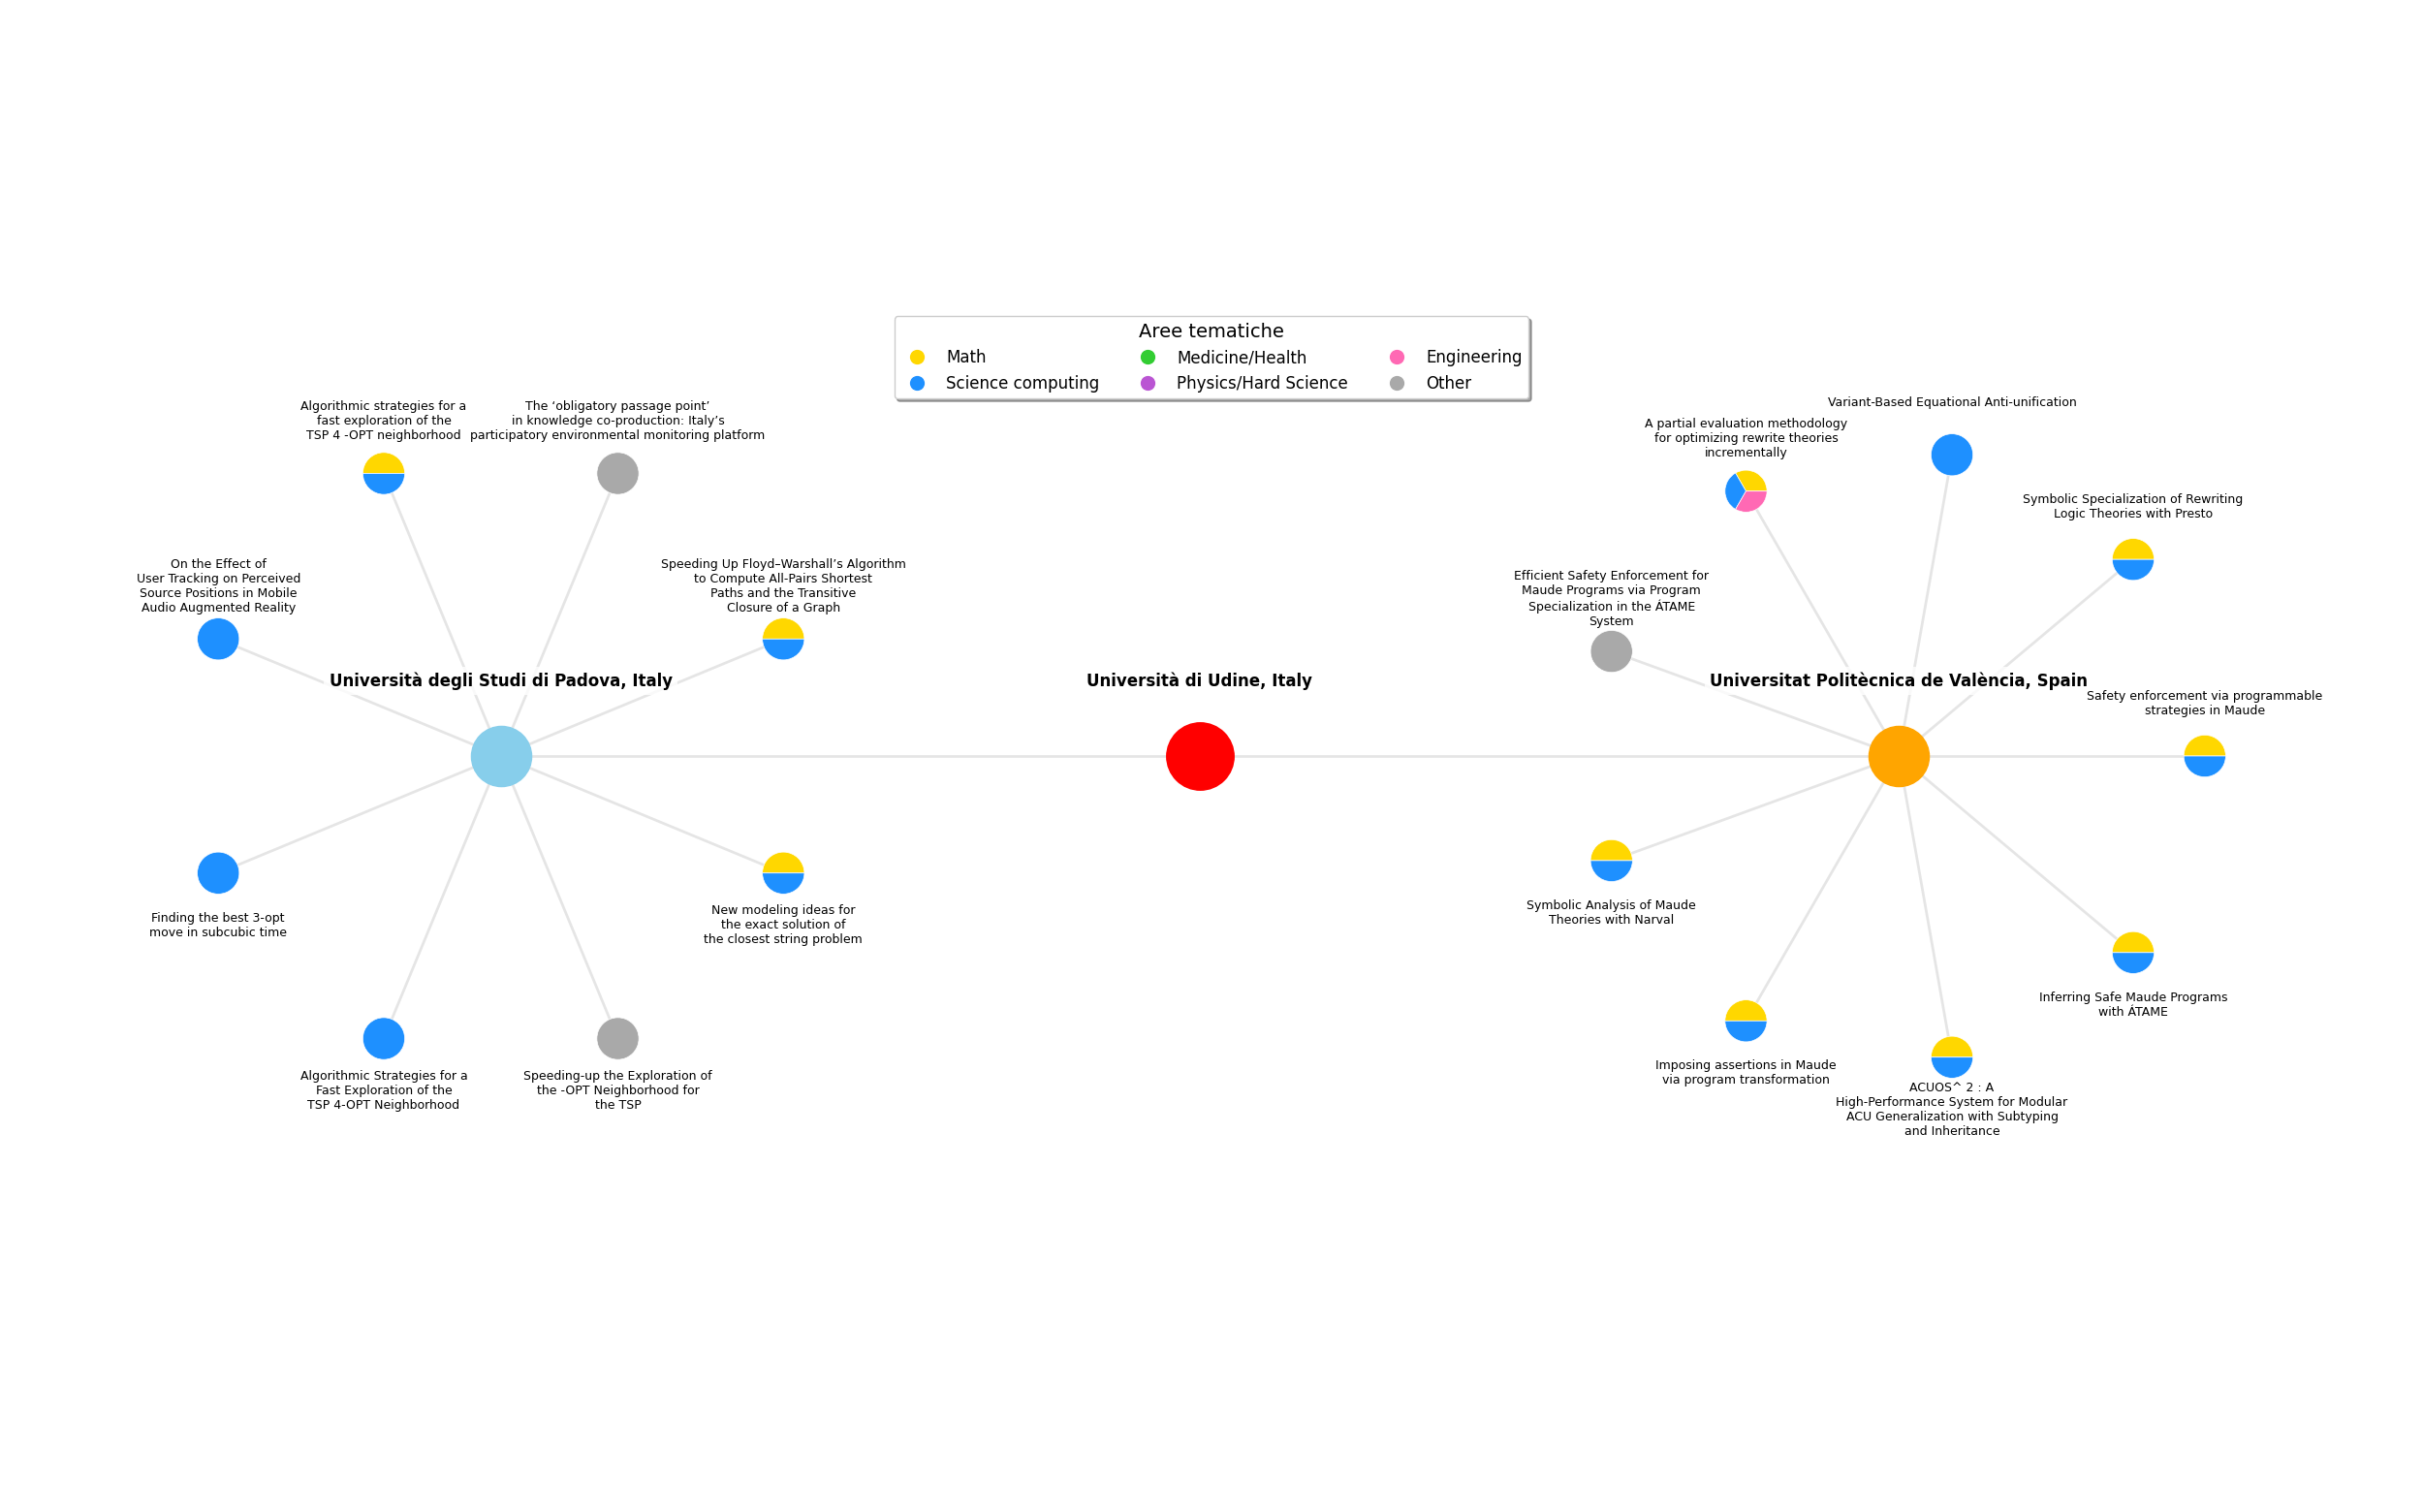

In [212]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from matplotlib.lines import Line2D
from matplotlib.patches import Wedge

# --- 1️⃣ CARICAMENTO E ANALISI ---
df = pd.read_csv("nuovo_dataset.csv")
df_udine = df[df["Affiliations"].str.contains("Udine", case=False, na=False)].copy()

italy_counter = Counter()
foreign_counter = Counter()

def clean_uni_name(aff_string):
    parts = [p.strip() for p in aff_string.split(",")]
    if len(parts) >= 2:
        return f"{parts[0]}, {parts[-1]}"
    return aff_string

for aff_string in df_udine["Affiliations"]:
    affiliations = [a.strip() for a in aff_string.split(";")]
    for aff in affiliations:
        if "udine" in aff.lower(): continue
        if "italy" in aff.lower():
            italy_counter[aff] += 1
        else:
            foreign_counter[aff] += 1

raw_italy = italy_counter.most_common(1)[0][0]
raw_foreign = foreign_counter.most_common(1)[0][0]

uni_italy_clean = clean_uni_name(raw_italy)
uni_foreign_clean = clean_uni_name(raw_foreign)
udine_clean = "Università di Udine, Italy"

# --- 2️⃣ CONFIGURAZIONE CATEGORIE ---
categories_map = {
    "Math": ["math", "algebra", "logic", "discrete", "geometry", "analis", "matemat", "combinatorics", "graph theory", "set theory", "formal proofs", "optimization", "calculus", "numerical", "complexity"],
    "Science computing": ["computer", "algorithm", "informatic", "computing", "systems", "intelligence", "ai", "software", "data", "cyber", "heuristics", "ceur", "acm", "ieee", "machine learning", "deep learning", "neural net", "signal processing", "vision", "image", "cloud", "iot", "programming", "simulation"],
    "Medicine/Health": ["medicine", "neuro", "clinical", "drug", "health", "pharmac", "genet", "cancer", "bio", "oncology", "epilepsy", "sleep", "seizure", "cerebellum", "sclerosis", "thrombosis", "brain", "patient", "therapy", "medical"],
    "Physics/Hard Science": ["physic", "nuclear", "chemical", "chemistry", "nanoscale", "molecule", "material", "energy", "atoms", "mechanics", "astronomy", "scientific"],
    "Engineering": ["engineering", "mechanical", "electrical", "transportation", "manufacturing", "robotics", "control", "automation", "electronics", "sensors"]
}

color_palette = {
    "Math": "#FFD700", "Science computing": "#1E90FF", "Medicine/Health": "#32CD32",
    "Physics/Hard Science": "#BA55D3", "Engineering": "#FF69B4", "Other": "#A9A9A9"
}

# Set per tenere traccia delle categorie effettivamente usate

def get_article_categories(row):
    full_text = " ".join([str(row.get("Title", "")), str(row.get("Author Keywords", "")), str(row.get("Index Keywords", ""))]).lower()
    found = [cat for cat, keywords in categories_map.items() if any(kw in full_text for kw in keywords)]
    final_cats = found if found else ["Other"]
    return final_cats

def sanitize_title(title):
    if not isinstance(title, str): return ""
    for ch in ["$", "{", "}", "\\"]: title = title.replace(ch, "")
    title = title.replace("textsf", "").replace("mathbf", "")
    words = title.split()
    # Aumentiamo leggermente il numero di parole per riga per allargare il blocco di testo
    if len(words) > 4:
        lines = [" ".join(words[i:i+4]) for i in range(0, len(words), 4)]
        title = "\n".join(lines)
    return title.strip()

# --- 3️⃣ COSTRUZIONE GRAFO ---
G = nx.Graph()
G.add_edge(udine_clean, uni_italy_clean)
G.add_edge(udine_clean, uni_foreign_clean)

left, right, center = [], [], []
article_data = {}

for _, row in df_udine.iterrows():
    aff_lower = str(row["Affiliations"]).lower()
    title = sanitize_title(row["Title"])
    article_data[title] = get_article_categories(row)
    
    has_it = raw_italy.lower() in aff_lower
    has_fr = raw_foreign.lower() in aff_lower

    if has_it and not has_fr:
        left.append(title); G.add_edge(uni_italy_clean, title)
    elif has_fr and not has_it:
        right.append(title); G.add_edge(uni_foreign_clean, title)
    elif has_it and has_fr:
        center.append(title); G.add_edge(uni_italy_clean, title); G.add_edge(uni_foreign_clean, title)

# --- 4️⃣ LAYOUT ---
pos = {udine_clean: (0, 0), uni_italy_clean: (-8, 0), uni_foreign_clean: (8, 0)}

def arrange_full_circle(center_pos, items, radius):
    if not items: return
    # Slittamento di 22.5 gradi per i numeri pari
    start_offset = np.radians(22.5) if len(items) % 2 == 0 else 0
    angles = np.linspace(0, 2*np.pi, len(items), endpoint=False) + start_offset
    for i, t in enumerate(items):
        pos[t] = (center_pos[0] + radius * np.cos(angles[i]), 
                  center_pos[1] + radius * np.sin(angles[i]))

# Aumentato il raggio per dare più spazio ai testi larghi
arrange_full_circle(pos[uni_italy_clean], left, 3.5)
arrange_full_circle(pos[uni_foreign_clean], right, 3.5)
arrange_full_circle((0, -4.5), center, 2.5)

# --- 5️⃣ DISEGNO ---
plt.figure(figsize=(32, 20))
ax = plt.gca()
ax.set_aspect('equal', adjustable='datalim')

nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color="black", width=2)
nx.draw_networkx_nodes(G, pos, [udine_clean], node_color='red', node_size=2500)
nx.draw_networkx_nodes(G, pos, [uni_italy_clean], node_color='skyblue', node_size=2000)
nx.draw_networkx_nodes(G, pos, [uni_foreign_clean], node_color='orange', node_size=2000)

def draw_pie_node(center, categories, radius=0.25):
    n = len(categories)
    angle_per_slice = 360 / n
    for i, cat in enumerate(categories):
        w = Wedge(center, radius, i*angle_per_slice, (i+1)*angle_per_slice, 
                  facecolor=color_palette.get(cat, "#A9A9A9"), edgecolor='white', linewidth=0.5, zorder=3)
        ax.add_patch(w)

all_articles = left + right + center
for node in all_articles:
    draw_pie_node(pos[node], article_data[node], radius=0.24)

# Etichette Università
for n in [udine_clean, uni_italy_clean, uni_foreign_clean]:
    x, y = pos[n]
    plt.text(x, y + 0.8, s=n, fontsize=12, fontweight='bold', ha='center', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Etichette Articoli
for art in all_articles:
    x, y = pos[art]
    if art in left: cp = pos[uni_italy_clean]
    elif art in right: cp = pos[uni_foreign_clean]
    else: cp = (0, -4.5)
    
    # Offset maggiore per evitare che il testo largo tocchi il nodo
    offset_y = 0.60 if y >= cp[1] else -0.60
    plt.text(x, y + offset_y, s=art, fontsize=9, ha="center", va="center",
             bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=0.3))

# --- LEGENDA FILTRATA ---
# Creiamo gli elementi solo per le aree che compaiono nel set used_categories
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=k, 
           markerfacecolor=v, markersize=12) 
    for k, v in color_palette.items()
]

plt.legend(handles=legend_elements, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.80), 
           title="Aree tematiche", 
           fontsize=12, 
           title_fontsize=14,
           ncol=3,                    
           frameon=True, 
           shadow=True)

plt.axis("off")
plt.show()

In [213]:
import pandas as pd
from collections import Counter
import re

# ===============================
# 1) Autore più collaborativo (GIÀ CALCOLATO DA TE)
# ===============================
# G_totale = nx.compose_all(grafi_per_anno.values())
# central_author = max(G_totale.degree, key=lambda x: x[1])[0]

print("Autore centrale globale:", central_author)

# ===============================
# 2) Filtra articoli dell'autore
# ===============================
author_name = central_author.lower()

author_df = df[
    df["Author full names"]
    .str.lower()
    .str.contains(re.escape(author_name), na=False)
]

# ===============================
# 3) Estrazione e conteggio università (esclusa Udine)
# ===============================
aff_counter = Counter()

for aff in author_df["Affiliations"].dropna():
    aff = aff.lower()

    # separazione affiliazioni multiple
    parts = re.split(r";|\|", aff)

    for p in parts:
        p = p.strip()

        # esclude Udine
        if "udine" in p:
            continue

        # filtra solo università
        if any(k in p for k in ["univ", "universit", "university"]):
            aff_counter[p] += 1

# ===============================
# 4) Università più collaborativa
# ===============================
if aff_counter:
    top_university, collaborations = aff_counter.most_common(1)[0]

    print("\nUniversità con cui collabora di più (esclusa Udine):")
    print(top_university)
    print("Numero collaborazioni:", collaborations)
else:
    print("\nNessuna collaborazione extra-Udine trovata.")


Autore centrale globale: Gigli Gian Luigi

Nessuna collaborazione extra-Udine trovata.


In [214]:
import pandas as pd
import re

# =====================================
# 1) Autore più collaborativo (GIÀ NOTO)
# =====================================
# G_totale = nx.compose_all(grafi_per_anno.values())
# central_author = max(G_totale.degree, key=lambda x: x[1])[0]

print("Autore centrale globale:", central_author)

# =====================================
# 2) Selezione articoli dell'autore
# =====================================
author_name = central_author.lower()

author_df = df[
    df["Author full names"]
    .str.lower()
    .str.contains(re.escape(author_name), na=False)
]

print(f"Numero articoli trovati: {len(author_df)}")

# =====================================
# 3) Estrazione affiliazioni
# =====================================
affiliations_set = set()

for aff in author_df["Affiliations"].dropna():
    parts = re.split(r";|\|", aff)

    for p in parts:
        p = p.strip()
        if p:
            affiliations_set.add(p)

# =====================================
# 4) Output ordinato
# =====================================
affiliations_list = sorted(affiliations_set)

print("\nElenco completo delle affiliazioni dell'autore:\n")
for a in affiliations_list:
    print("-", a)


Autore centrale globale: Gigli Gian Luigi
Numero articoli trovati: 0

Elenco completo delle affiliazioni dell'autore:



In [215]:
import re

# =========================================
# Autore più centrale (già noto, già pulito)
# =========================================
# central_author = "Nome Cognome"

print("Autore più centrale:", central_author)

# =========================================
# Funzione di pulizia (solo per il dataset)
# =========================================
def clean_author_name(name):
    return (
        re.sub(r"\s*\([^)]*\)", "", name)  # rimuove (ID)
        .replace(",", "")                 # rimuove virgole
        .strip()
    )

# =========================================
# Numero di articoli nel dataset
# =========================================
num_articles = 0

for authors in df["Author full names"].dropna():

    author_list = [
        clean_author_name(a)
        for a in authors.split(";")
    ]

    if central_author in author_list:
        num_articles += 1

# =========================================
# Numero di collaborazioni (dal grafo)
# =========================================
num_collaborations = dict(G_totale.degree)[central_author]

# =========================================
# Output finale
# =========================================
print("Numero di articoli:", num_articles)
print("Numero di collaborazioni (grado nel grafo):", num_collaborations)


Autore più centrale: Gigli Gian Luigi
Numero di articoli: 39
Numero di collaborazioni (grado nel grafo): 119


In [216]:
import re

# =========================================
# Autore centrale (già noto, già pulito)
# =========================================
print("Autore più centrale:", central_author,"\n")

# =========================================
# Funzioni di pulizia
# =========================================
def clean_author_name(name):
    return (
        re.sub(r"\s*\([^)]*\)", "", name)
        .replace(",", "")
        .strip()
    )

def extract_universities(affiliation):
    # spezza affiliazioni multiple
    parts = re.split(r";|\|", affiliation)
    universities = []

    for p in parts:
        p = p.strip()
        if any(k in p.lower() for k in ["univ", "universit", "university"]):
            universities.append(p)

    return universities

# =========================================
# Estrazione affiliation extra-Udine
# =========================================
other_universities = set()

for _, row in df.iterrows():

    # ---- controllo autore (non in forma base nel dataset)
    authors_raw = row["Author full names"]
    if pd.isna(authors_raw):
        continue

    author_list = [
        clean_author_name(a)
        for a in authors_raw.split(";")
    ]

    if central_author not in author_list:
        continue

    # ---- estrazione affiliation
    affiliations = row["Affiliations"]
    if pd.isna(affiliations):
        continue

    universities = extract_universities(affiliations)

    for u in universities:
        if "udine" not in u.lower():
            other_universities.add(u)

# =========================================
# Output
# =========================================
print(central_author,"è affiliato all'Università degli Studi di Udine e ha collaborato con le seguenti università:")
for u in sorted(other_universities):
    print("-", u)


Autore più centrale: Gigli Gian Luigi 

Gigli Gian Luigi è affiliato all'Università degli Studi di Udine e ha collaborato con le seguenti università:
- Alma Mater Studiorum Università di Bologna, Bologna, BO, Italy
- Centre de Recherche en Biologie Structurale, Université McGill, Montreal, QC, Canada
- Department of Biochemistry, Centre Hospitalier Universitaire de Saint-Étienne, Saint-Etienne, Auvergne-Rhone-Alpes, France
- Department of Biomedical, Università degli Studi di Modena e Reggio Emilia, Modena, MO, Italy
- Department of Clinical Neurophysiology and Sleep Center, Université de Lille, Lille, Hauts-de-France, France
- Department of Human Genetics, Université McGill, Montreal, QC, Canada
- Department of Medical Sciences and Public Health, Università degli Studi di Cagliari, Cagliari, CA, Italy
- Department of Neurological Sciences, Università Vita-Salute San Raffaele, Milan, MI, Italy
- Department of Neurology and Center of Clinical Neuroscience, Charles University, Prague, Cz

In [217]:
import re
import pandas as pd
from collections import Counter

# =========================================
# Autore centrale (già noto, già pulito)
# =========================================
print("Autore più centrale:", central_author, "\n")

# =========================================
# Funzioni di pulizia
# =========================================
def clean_author_name(name):
    return (
        re.sub(r"\s*\([^)]*\)", "", name)
        .replace(",", "")
        .strip()
    )

def extract_universities(affiliation):
    # spezza affiliazioni multiple
    parts = re.split(r";|\|", affiliation)
    universities = []

    for p in parts:
        p = p.strip()
        if any(k in p.lower() for k in ["univ", "universit", "university"]):
            universities.append(p)

    return universities

# =========================================
# Estrazione affiliation extra-Udine con Conteggio
# =========================================
# Sostituiamo il set() con Counter() per contare le occorrenze
university_counts = Counter()

for _, row in df.iterrows():

    # ---- controllo autore
    authors_raw = row["Author full names"]
    if pd.isna(authors_raw):
        continue

    author_list = [
        clean_author_name(a)
        for a in authors_raw.split(";")
    ]

    if central_author not in author_list:
        continue

    # ---- estrazione affiliation
    affiliations = row["Affiliations"]
    if pd.isna(affiliations):
        continue

    universities = extract_universities(affiliations)

    # Usiamo un set temporaneo per ogni riga se vuoi contare 1 collaborazione 
    # per ogni paper, anche se l'università appare più volte nello stesso paper
    unique_unis_in_paper = set()
    for u in universities:
        if "udine" not in u.lower():
            unique_unis_in_paper.add(u)
    
    # Aggiorniamo il contatore globale
    university_counts.update(unique_unis_in_paper)

# =========================================
# Output Ordinato per numero di collaborazioni
# =========================================
print(f"{central_author} è affiliato all'Università degli Studi di Udine e ha collaborato con le seguenti università:")

# Ordiniamo i risultati: dai più frequenti ai meno frequenti
for university, count in university_counts.most_common():
    print(f"- {university} ({count} collaborazioni)")

print

Autore più centrale: Gigli Gian Luigi 

Gigli Gian Luigi è affiliato all'Università degli Studi di Udine e ha collaborato con le seguenti università:
- Université Claude Bernard Lyon 1, Villeurbanne, Auvergne-Rhone-Alpes, France (4 collaborazioni)
- Sleep disorder Unit, Hôpital Universitaire Carémeau, Nimes, Occitania, France (3 collaborazioni)
- Department of Neurology, Medizinische Universitat Innsbruck, Innsbruck, Tyrol, Austria (3 collaborazioni)
- Department of Neurology, Philipps-Universität Marburg, Marburg, Hessen, Germany (3 collaborazioni)
- University of Oxford Medical Sciences Division, Oxford, Oxfordshire, United Kingdom (3 collaborazioni)
- Department of Neurology and Neurosurgery, Université McGill, Montreal, QC, Canada (3 collaborazioni)
- Department of Psychology, Université du Québec à Montréal, Montreal, QC, Canada (3 collaborazioni)
- Department of Medical Sciences and Public Health, Università degli Studi di Cagliari, Cagliari, CA, Italy (3 collaborazioni)
- Depart

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [218]:
import re
import pandas as pd
from collections import Counter

# =========================================
# Funzioni di pulizia e utility
# =========================================
def clean_author_name(name):
    return re.sub(r"\s*\([^)]*\)", "", str(name)).replace(",", "").strip()

def extract_universities(affiliation):
    parts = re.split(r";|\|", str(affiliation))
    return [p.strip() for p in parts if any(k in p.lower() for k in ["univ", "universit", "university"])]

# =========================================
# Estrazione con check collaboratori Udine
# =========================================
university_counts = Counter()

for _, row in df.iterrows():
    # 1. Verifica presenza autore centrale
    authors_raw = row["Author full names"]
    if pd.isna(authors_raw): continue
    
    author_list = [clean_author_name(a) for a in str(authors_raw).split(";")]
    if central_author not in author_list:
        continue

    # 2. Analisi "Authors with affiliations" per Udine
    # Formato tipico: Cognome, N. (Univ A); Rossi, M. (Univ Udine)
    authors_with_affs = str(row.get("Authors with affiliations", ""))
    
    # Cerchiamo quanti sono affiliati a Udine in questo paper
    # Usiamo una regex per trovare tutti i nomi che hanno "Udine" tra parentesi
    udine_affiliates = re.findall(r"([^;]+)\s*\([^)]*Udine[^)]*\)", authors_with_affs, re.IGNORECASE)
    
    # Puliamo i nomi dei colleghi di Udine trovati
    udine_colleagues = [clean_author_name(name.split(",")[0]) for name in udine_affiliates]
    
    # Check: ci sono altri di Udine oltre all'autore centrale?
    other_udine_present = any(name for name in udine_colleagues if name != central_author.split()[-1]) 
    # Nota: il check sopra è semplificato sul cognome, se hai nomi completi usa central_author

    # 3. Estrazione affiliazioni dal paper
    affiliations = row["Affiliations"]
    if pd.isna(affiliations): continue
    
    universities = extract_universities(affiliations)
    unique_unis_in_paper = set()

    for u in universities:
        is_udine = "udine" in u.lower()
        
        if is_udine:
            # Conta Udine solo se ci sono altri colleghi affiliati
            if other_udine_present:
                unique_unis_in_paper.add(u)
        else:
            # Le altre università si aggiungono sempre
            unique_unis_in_paper.add(u)
    
    university_counts.update(unique_unis_in_paper)

# =========================================
# Output
# =========================================
print(f"Collaborazioni di {central_author} (inclusa Udine se con colleghi):")
for university, count in university_counts.most_common():
    print(f"- {university} ({count} collaborazioni)")

Collaborazioni di Gigli Gian Luigi (inclusa Udine se con colleghi):
- Université Claude Bernard Lyon 1, Villeurbanne, Auvergne-Rhone-Alpes, France (4 collaborazioni)
- Sleep disorder Unit, Hôpital Universitaire Carémeau, Nimes, Occitania, France (3 collaborazioni)
- Department of Neurology, Medizinische Universitat Innsbruck, Innsbruck, Tyrol, Austria (3 collaborazioni)
- Department of Neurology, Philipps-Universität Marburg, Marburg, Hessen, Germany (3 collaborazioni)
- University of Oxford Medical Sciences Division, Oxford, Oxfordshire, United Kingdom (3 collaborazioni)
- Department of Neurology and Neurosurgery, Université McGill, Montreal, QC, Canada (3 collaborazioni)
- Department of Psychology, Université du Québec à Montréal, Montreal, QC, Canada (3 collaborazioni)
- Department of Medical Sciences and Public Health, Università degli Studi di Cagliari, Cagliari, CA, Italy (3 collaborazioni)
- Department of Neurological Sciences, Università Vita-Salute San Raffaele, Milan, MI, Ita

In [225]:
import re
import pandas as pd
from collections import Counter

# =========================================
# 1. PREPARAZIONE (Assicurati che authors_list esista)
# =========================================
central_author_clean = central_author.replace(",", "").strip()

if "authors_list" not in df.columns:
    df["authors_list"] = df["Author full names"].str.split(";").apply(
        lambda x: [re.sub(r"\s*\([^)]*\)", "", str(a)).replace(",", "").strip() for a in x] 
        if isinstance(x, list) or pd.notna(x) else []
    )

# =========================================
# 2. ESTRAZIONE COLLABORAZIONI
# =========================================
university_counts = Counter()

# Filtriamo il dataframe per lavorare solo sugli articoli dell'autore centrale
df_central_author = df[df["authors_list"].apply(lambda x: central_author_clean in x if isinstance(x, list) else False)].copy()

for _, row in df_central_author.iterrows():
    
    # --- Analisi Udine ---
    # Contiamo quante volte appare "Udine" nel campo "Authors with affiliations"
    authors_with_affs = str(row.get("Authors with affiliations", ""))
    udine_occurrences = len(re.findall(r"Udine", authors_with_affs, re.IGNORECASE))
    
    # Collaborazione interna se Udine appare più di 1 volta
    internal_collab_udine = udine_occurrences > 1

    # --- Estrazione Università ---
    affiliations = row.get("Affiliations", "")
    if pd.isna(affiliations): continue
    
    # Estraiamo le università dalla riga
    parts = re.split(r";|\|", str(affiliations))
    universities = [p.strip() for p in parts if any(k in p.lower() for k in ["univ", "universit", "university"])]
    
    unique_unis_in_paper = set()
    for u in universities:
        is_udine = "udine" in u.lower()
        
        if is_udine:
            if internal_collab_udine:
                unique_unis_in_paper.add(u)
        else:
            # Altre università aggiunte sempre
            unique_unis_in_paper.add(u)
    
    university_counts.update(unique_unis_in_paper)

# =========================================
# 3. OUTPUT
# =========================================
print(f"ANALISI COLLABORAZIONI PER: {central_author_clean.upper()}")
print(f"Basata su {len(df_central_author)} articoli totali.")
print("-" * 80)

if not university_counts:
    print("Nessuna collaborazione trovata con i criteri specificati.")
else:
    for university, count in university_counts.most_common():
        print(f"- {university:70} | {count} collaborazioni")

ANALISI COLLABORAZIONI PER: GIGLI GIAN LUIGI
Basata su 39 articoli totali.
--------------------------------------------------------------------------------
- Università degli Studi di Udine, Dipartimento di Area Medica, Udine, UD, Italy | 23 collaborazioni
- Università degli Studi di Udine, Udine, UD, Italy                      | 19 collaborazioni
- Department of Neuroscience, Policlinico Universitario, Udine, Udine, UD, Italy | 15 collaborazioni
- Neurological Clinic, Presidio Ospedaliero Universitario Santa Maria della Misericordia , Udine, Udine, UD, Italy | 13 collaborazioni
- Department of Mathematics, Università degli Studi di Udine, Udine, UD, Italy | 11 collaborazioni
- Department of Mathematics and Physics, Università degli Studi di Udine, Udine, UD, Italy | 10 collaborazioni
- Department of Neuroscience, Presidio Ospedaliero Universitario Santa Maria della Misericordia , Udine, Udine, UD, Italy | 6 collaborazioni
- Neurological Clinic, Policlinico Universitario, Udine, Udine,

In [231]:
from collections import Counter

# =========================================
# 1. DEFINIZIONE DELLE REGOLE DI RAGGRUPPAMENTO
# =========================================
def get_macro_category(uni_name):
    u = uni_name.lower()
    
    # 1. STEM (Matematica, Fisica, Informatica)
    if any(k in u for k in ["mathematics", "physics", "matematica", "fisica"]):
        return "Area STEM (Matematica/Fisica)"
    
    # 2. CLINICA & OSPEDALIERA (Reparti, Ospedale, Clinica)
    if any(k in u for k in ["clinic", "hospital", "ospedaliero", "misericordia", "policlinico", "unit", "neuroscience"]):
        # Un piccolo check per i servizi specialistici (opzionale, se vuoi separarli)
        if any(k in u for k in ["radiology", "hematology", "pediatric", "oncology", "infectious", "laboratory"]):
             return "Servizi Specialistici Ospedalieri"
        return "Area Clinica & Ospedaliera"
    
    # 3. AREA MEDICA / UNIVERSITÀ (DAME, Dipartimento, Ricerca)
    if any(k in u for k in ["area medica", "dame", "medical area", "pathology", "hygiene", "università degli studi di udine"]):
        return "Area Medica & Ricerca Universitaria"
    
    # Se non rientra in Udine o in queste categorie, restituiamo il nome originale
    return uni_name

# =========================================
# 2. APPLICAZIONE DEL RAGGRUPPAMENTO
# =========================================
grouped_counts = Counter()

for uni, count in university_counts.items():
    if "udine" in uni.lower():
        category = get_macro_category(uni)
        grouped_counts[category] += count
    else:
        # Teniamo le università esterne/italiane così come sono
        grouped_counts[uni] += count

# =========================================
# 3. OUTPUT DEI RISULTATI RAGGRUPPATI (UDINE)
# =========================================
print(f"COLLABORAZIONI RAGGRUPPATE PER: {central_author_clean.upper()}")
print("-" * 80)

# Filtriamo solo le macro-categorie di Udine per la visualizzazione
for cat, count in grouped_counts.most_common():
    if any(k in cat for k in ["Area", "Servizi", "Udine"]): # Filtro per mostrare Udine
        print(f"- {cat:45} | {count} collaborazioni")

COLLABORAZIONI RAGGRUPPATE PER: GIGLI GIAN LUIGI
--------------------------------------------------------------------------------
- Area Clinica & Ospedaliera                    | 61 collaborazioni
- Area Medica & Ricerca Universitaria           | 46 collaborazioni
- Area STEM (Matematica/Fisica)                 | 21 collaborazioni
- Servizi Specialistici Ospedalieri             | 8 collaborazioni


In [254]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
from collections import Counter
import math

# [Logica di raggruppamento invariata come da tua richiesta precedente]
def get_custom_category(uni_name):
    u = uni_name.lower()
    if "udine" not in u:
        return uni_name
    if any(k in u for k in ["area medica", "dame"]):
        return "Dipartimento di Area Medica (Udine)"
    if "policlinico" in u:
        return "Policlinico Universitario (Udine)"
    if any(k in u for k in ["p.o.u.", "misericordia", "presidio ospedaliero universitario"]):
        return "P.O.U. Santa Maria della Misericordia (Udine)"
    if "mathematics" in u:
        return "DMIF (Udine)"
    return uni_name

grouped_counts = Counter()
grouped_details = {} 
for uni, count in university_counts.items():
    category = get_custom_category(uni)
    grouped_counts[category] += count
    if category not in grouped_details: grouped_details[category] = []
    if category != uni:
        clean_name = uni.split(",")[0].strip()
        grouped_details[category].append(f"• {clean_name} ({count})")

# Configurazione Colori
pink_shades = {
    "Dipartimento di Area Medica (Udine)": "#C71585",
    "Policlinico Universitario (Udine)": "#FF1493",
    "P.O.U. Santa Maria della Misericordia (Udine)": "#FF69B4",
    "DMIF (Udine)": "#DB7093",
    "Udine: Altre Sedi": "#FFB6C1"
}

G = nx.Graph()
G.add_node(central_author, type='central')
for uni, count in grouped_counts.items():
    is_udine = "udine" in uni.lower() or uni in pink_shades
    u_type = "internal" if is_udine else ("italian" if any(k in uni.lower() for k in ["italy", "italia"]) else "foreign")
    G.add_node(uni, type=u_type, weight=count)
    G.add_edge(central_author, uni, weight=count)

# Distanza aumentata (k=0.6)
pos = nx.spring_layout(G, k=0.6, weight='weight', seed=42)

node_traces = []
legend_added = set()

# Archi
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]; x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None]); edge_y.extend([y0, y1, None])
edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=0.7, color='#E5E5E5'), hoverinfo='none', mode='lines', showlegend=False)

# Nodi con crescita ridotta
for node in G.nodes():
    if node == central_author: continue
    data = G.nodes[node]
    count = data['weight']
    x, y = pos[node]
    
    if data['type'] == "internal":
        color = pink_shades.get(node, pink_shades["Udine: Altre Sedi"])
        category_name = node if node in pink_shades else "Udine: Altre Sedi"
    else:
        color = 'skyblue' if data['type'] == "italian" else 'orange'
        category_name = "Università Italiana" if data['type'] == "italian" else "Università Estera"

    # --- CAMBIO VALORE QUI: Crescita meno aggressiva ---
    # Prima era: 18 + (count * 2.2)
    # Ora usiamo un moltiplicatore ridotto per non far esplodere i nodi di Udine
    calculated_size = 15 + (count * 1.2) 

    details = "<br>".join(grouped_details.get(node, []))
    hover_label = f"<b>{node}</b><br>Collaborazioni: {count}"
    if details: hover_label += f"<br><br>Sedi incluse:<br>{details}"

    show_in_legend = category_name not in legend_added
    if show_in_legend: legend_added.add(category_name)

    node_traces.append(go.Scatter(
        x=[x], y=[y], mode='markers',
        name=category_name,
        marker=dict(color=color, size=calculated_size, line=dict(width=1, color='white')),
        text=hover_label, hoverinfo='text',
        showlegend=show_in_legend,
        legendgroup=category_name
    ))

central_trace = go.Scatter(
    x=[pos[central_author][0]], y=[pos[central_author][1]],
    mode='markers+text', text=[f"<b>{central_author}</b>"], textposition="top center",
    hoverinfo='none', marker=dict(color='red', size=22, line=dict(width=2, color='white')),
    showlegend=False
)

fig = go.Figure(data=[edge_trace, *node_traces, central_trace])
fig.update_layout(
    title=dict(text=f"Affiliazioni con cui ha collaborato {central_author}", x=0.5),
    width=1400, height=850,
    legend=dict(
        title_text="Legenda",
        x=1.02, y=1.0, # Destra in alto
        xanchor="left", yanchor="top",
        bordercolor="Gray", borderwidth=1
    ),
    margin=dict(r=250),
    paper_bgcolor='white', plot_bgcolor='white',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
)
fig.show()

In [230]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import re

# =========================================
# 1. PREPARAZIONE DATI
# =========================================
G = nx.Graph()

# Nodo centrale
G.add_node(central_author, type='central', weight=0)

for uni, count in university_counts.items():
    is_udine = "udine" in uni.lower()
    is_italy = any(k in uni.lower() for k in ["italy", "italia"])
    
    # Definiamo il tipo per il colore
    if is_udine:
        u_type = "internal"
    elif is_italy:
        u_type = "italian"
    else:
        u_type = "foreign"
    
    G.add_node(uni, type=u_type, weight=count)
    G.add_edge(central_author, uni, weight=count)

# =========================================
# 2. LAYOUT DINAMICO (Schiacciato)
# =========================================
pos = nx.spring_layout(G, k=1, weight='weight', seed=42) 

for node in pos:
    pos[node][1] = pos[node][1] * 0.5 

# =========================================
# 3. CREAZIONE TRACCE PLOTLY
# =========================================

# --- ARCHI ---
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]; x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None]); edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y, line=dict(width=1, color='#D3D3D3'),
    hoverinfo='none', mode='lines', showlegend=False
)

# --- NODI UNIVERSITÀ ---
node_x, node_y, node_text, node_color, node_size = [], [], [], [], []

for node in G.nodes():
    if node == central_author: continue
    
    x, y = pos[node]
    node_x.append(x); node_y.append(y)
    
    data = G.nodes[node]
    # LOGICA COLORI AGGIORNATA
    if data['type'] == 'internal':
        color = '#FF1493'
    else:
        color = 'skyblue' if data['type'] == 'italian' else 'orange'
        
    node_color.append(color)
    node_size.append(12 + data['weight'] * 4)
    node_text.append(f"{node}<br>Collaborazioni: {data['weight']}")

node_trace = go.Scatter(
    x=node_x, y=node_y, mode='markers', hoverinfo='text', text=node_text,
    marker=dict(color=node_color, size=node_size, line=dict(width=1.5, color='white')),
    showlegend=False
)

# --- NODO CENTRALE ---
central_node_trace = go.Scatter(
    x=[pos[central_author][0]], y=[pos[central_author][1]],
    mode='markers+text', text=[central_author],
    textposition="top center", hoverinfo='none',
    marker=dict(color='red', size=18, line=dict(width=2, color='white')),
    textfont=dict(size=12, color='black', family="Arial Black"),
    name='Autore Centrale', showlegend=True
)

# --- TRACCE FANTASMA PER LEGENDA (Incluso ROSA) ---
legend_internal = go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=10, color='#FF1493'),
    name='Collaborazione Interna (Udine)', showlegend=True
)
legend_it = go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=10, color='skyblue'),
    name='Università Italiana', showlegend=True
)
legend_fr = go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=10, color='orange'),
    name='Università Estera', showlegend=True
)

# =========================================
# 4. CONFIGURAZIONE LAYOUT FINALE
# =========================================
fig = go.Figure(data=[edge_trace, node_trace, central_node_trace, legend_internal, legend_it, legend_fr])

fig.update_layout(
    title=dict(text=f"Network Collaborazioni: {central_author}", x=0.5, y=0.95),
    showlegend=True,
    legend=dict(
        yanchor="top", y=0.99, xanchor="right", x=0.99,
        bordercolor="Gray", borderwidth=1
    ),
    hovermode='closest',
    margin=dict(b=20, l=40, r=40, t=60),
    width=1200, height=500,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    paper_bgcolor='white', plot_bgcolor='white'
)

fig.show()

In [256]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
from collections import Counter

# --- 1. Logica di raggruppamento ---
def get_custom_category(uni_name):
    u = uni_name.lower()
    if "udine" not in u:
        return uni_name
    if any(k in u for k in ["area medica", "dame"]):
        return "Dipartimento di Area Medica (Udine)"
    if "policlinico" in u:
        return "Policlinico Universitario (Udine)"
    if any(k in u for k in ["p.o.u.", "misericordia", "presidio ospedaliero universitario"]):
        return "P.O.U. Santa Maria della Misericordia (Udine)"
    if "mathematics" in u:
        return "DMIF (Udine)"
    return "Udine: Altre Sedi"

# Assumendo che university_counts e central_author siano già definiti
grouped_counts = Counter()
grouped_details = {} 

for uni, count in university_counts.items():
    category = get_custom_category(uni)
    grouped_counts[category] += count
    if category not in grouped_details: 
        grouped_details[category] = []
    if category != uni:
        clean_name = uni.split(",")[0].strip()
        grouped_details[category].append(f"• {clean_name} ({count})")

# --- 2. Configurazione Colori ---
pink_shades = {
    "Dipartimento di Area Medica (Udine)": "#C71585",
    "Policlinico Universitario (Udine)": "#FF1493",
    "P.O.U. Santa Maria della Misericordia (Udine)": "#FF69B4",
    "DMIF (Udine)": "#DB7093",
    "Udine: Altre Sedi": "#FFB6C1"
}

# --- 3. Creazione Grafo ---
G = nx.Graph()
G.add_node(central_author, type='central')

for uni, count in grouped_counts.items():
    is_udine = "udine" in uni.lower() or uni in pink_shades
    u_type = "internal" if is_udine else ("italian" if any(k in uni.lower() for k in ["italy", "italia"]) else "foreign")
    G.add_node(uni, type=u_type, weight=count)
    G.add_edge(central_author, uni, weight=count)

# Layout posizionamento
pos = nx.spring_layout(G, k=0.6, weight='weight', seed=42)

# --- 4. Creazione Tracce Plotly ---
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y, 
    line=dict(width=0.7, color='#E5E5E5'), 
    hoverinfo='none', mode='lines', showlegend=False
)

node_traces = []
legend_added = set()

# ORDINAMENTO ALFABETICO: Applichiamo sorted() ai nodi per la legenda
for node in sorted(G.nodes()):
    if node == central_author: 
        continue
        
    data = G.nodes[node]
    count = data['weight']
    x, y = pos[node]
    
    # Colori e Categorie
    if data['type'] == "internal":
        color = pink_shades.get(node, pink_shades["Udine: Altre Sedi"])
        category_name = node
    else:
        color = 'skyblue' if data['type'] == "italian" else 'orange'
        category_name = "Università Italiana" if data['type'] == "italian" else "Università Estera"

    # Dimensione nodi proporzionale
    calculated_size = 15 + (count * 1.2) 

    # Hover text
    details = "<br>".join(grouped_details.get(node, []))
    hover_label = f"<b>{node}</b><br>Collaborazioni: {count}"
    if details: 
        hover_label += f"<br><br>Sedi incluse:<br>{details}"

    # Gestione Legenda
    show_in_legend = category_name not in legend_added
    if show_in_legend: 
        legend_added.add(category_name)

    node_traces.append(go.Scatter(
        x=[x], y=[y], mode='markers',
        name=category_name,
        marker=dict(color=color, size=calculated_size, line=dict(width=1, color='white')),
        text=hover_label, hoverinfo='text',
        showlegend=show_in_legend,
        legendgroup=category_name
    ))

# Nodo Centrale
central_trace = go.Scatter(
    x=[pos[central_author][0]], y=[pos[central_author][1]],
    mode='markers+text', text=[f"<b>{central_author}</b>"], textposition="top center",
    hoverinfo='none', marker=dict(color='red', size=22, line=dict(width=2, color='white')),
    showlegend=False
)

# --- 5. Generazione Figura ---
fig = go.Figure(data=[edge_trace, *node_traces, central_trace])

fig.update_layout(
    title=dict(text=f"Affiliazioni con cui ha collaborato {central_author}", x=0.5),
    width=1400, height=850,
    legend=dict(
        title_text="Legenda",
        traceorder="normal",
        x=1.02, y=1.0,
        xanchor="left", yanchor="top",
        bordercolor="Gray", borderwidth=1
    ),
    margin=dict(r=250),
    paper_bgcolor='white', plot_bgcolor='white',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
)

fig.show()

In [262]:
import pandas as pd
import re
from collections import Counter

# 1. Caricamento del file
df = pd.read_csv('nuovo_dataset.csv')

# 2. Funzione robusta per pulire i nomi (rimuove ID e virgole)
def clean_author_names(val):
    if not isinstance(val, str):
        return []
    # Splitta per punto e virgola
    raw_list = val.split(";")
    cleaned = []
    for a in raw_list:
        # Rimuove il contenuto tra parentesi (ID), toglie virgole e pulisce spazi
        name = re.sub(r"\s*\([^)]*\)", "", a).replace(",", "").strip()
        if name:
            cleaned.append(name)
    return cleaned

# Applichiamo la pulizia
df["authors_list"] = df["Author full names"].apply(clean_author_names)

# 3. Identificazione dell'autore più collaborativo (Gigli Gian Luigi)
all_authors_flat = [author for sublist in df["authors_list"] for author in sublist]
author_counts = Counter(all_authors_flat)
top_author = author_counts.most_common(1)[0][0]

print(f"Risultati per l'autore più collaborativo: {top_author}\n")

# 4. Filtro degli articoli e selezione delle colonne (senza Index Keywords)
mask = df["authors_list"].apply(lambda x: top_author in x)
articoli_autore = df[mask].copy()

# Selezioniamo solo Source Title e Author Keywords
risultato = articoli_autore[['Source title', 'Author Keywords']].copy()

# Pulizia dei valori nulli per una visualizzazione ordinata
risultato['Author Keywords'] = risultato['Author Keywords'].fillna('Nessuna keyword inserita')

# 5. Visualizzazione
print(f"--- ELENCO PUBBLICAZIONI: {top_author.upper()} ---")
pd.set_option('display.max_colwidth', None) # Evita che il testo venga tagliato
print(risultato.to_string(index=False))

# Analisi rapida delle sole Author Keywords più frequenti
print("\n--- LE 10 KEYWORD DELL'AUTORE PIÙ FREQUENTI ---")
all_author_kws = articoli_autore['Author Keywords'].str.cat(sep='; ')
clean_kws = [k.strip().lower() for k in str(all_author_kws).split(';') if k.strip() and k.lower() != 'nan']
print(pd.Series(clean_kws).value_counts().head(10))

Risultati per l'autore più collaborativo: Gigli Gian Luigi

--- ELENCO PUBBLICAZIONI: GIGLI GIAN LUIGI ---
                                    Source title                                                                                                                                                 Author Keywords
             Journal of Clinical Neurophysiology                                                        "Fast-charge"; "Slow-charge"; Intraoperative monitoring; Transcranial electrical motor-evoked potentials
             Journal of Clinical Neurophysiology                                                                        Awake craniotomy; Cortical stimulation; Epileptiform activity; Intraoperative monitoring
                            Journal of Neurology                                                                                         CACNA1A; Cerebellar atrophy; Channelopathy; Epilepsy; Hereditary ataxia
                                eNeurologicalSci         

In [266]:
import pandas as pd
import re
from collections import Counter

# 1. Caricamento del file
df = pd.read_csv('nuovo_dataset.csv')

# 2. Funzione robusta per pulire i nomi (rimuove ID e virgole)
def clean_author_names(val):
    if not isinstance(val, str):
        return []
    # Splitta per punto e virgola
    raw_list = val.split(";")
    cleaned = []
    for a in raw_list:
        # Rimuove il contenuto tra parentesi (ID), toglie virgole e pulisce spazi
        name = re.sub(r"\s*\([^)]*\)", "", a).replace(",", "").strip()
        if name:
            cleaned.append(name)
    return cleaned

# Applichiamo la pulizia
df["authors_list"] = df["Author full names"].apply(clean_author_names)

# 3. Identificazione dell'autore più collaborativo (Gigli Gian Luigi)
all_authors_flat = [author for sublist in df["authors_list"] for author in sublist]
author_counts = Counter(all_authors_flat)
top_author = author_counts.most_common(1)[0][0]

print(f"Risultati per l'autore più collaborativo: {top_author}\n")

# 4. Filtro degli articoli e selezione delle colonne (senza Index Keywords)
mask = df["authors_list"].apply(lambda x: top_author in x)
articoli_autore = df[mask].copy()

# Selezioniamo solo Source Title e Author Keywords
risultato = articoli_autore[['Source title']].copy()


# 5. Visualizzazione
print(f"--- ELENCO PUBBLICAZIONI: {top_author.upper()} ---")
pd.set_option('display.max_colwidth', None) # Evita che il testo venga tagliato
print(risultato.to_string(index=False))



Risultati per l'autore più collaborativo: Gigli Gian Luigi

--- ELENCO PUBBLICAZIONI: GIGLI GIAN LUIGI ---
                                    Source title
             Journal of Clinical Neurophysiology
             Journal of Clinical Neurophysiology
                            Journal of Neurology
                                eNeurologicalSci
                                           Brain
                                  Acta Biomedica
                                         Seizure
        Multiple Sclerosis and Related Disorders
          Journal of Thrombosis and Thrombolysis
                            Journal of Neurology
                            Journal of Neurology
                                       Neurology
                            Journal of Neurology
                            Neuroscience Letters
                   Epilepsy and Behavior Reports
               Expert Opinion on Pharmacotherapy
                           Neurological Sciences
Expert Opin

In [267]:
import pandas as pd
import re
import numpy as np
import plotly.graph_objects as go
import networkx as nx

# 1. Preparazione Dati e Pulizia
df = pd.read_csv('nuovo_dataset.csv')

def clean_author_names(val):
    if not isinstance(val, str): return []
    return [re.sub(r"\s*\([^)]*\)", "", a).replace(",", "").strip() for a in val.split(";")]

df["authors_list"] = df["Author full names"].apply(clean_author_names)

# 2. Definizione Regole di Raggruppamento
def get_category(source_title):
    s = str(source_title).lower()
    # Mappatura basata sulla tua analisi
    if any(k in s for k in ["epilepsia", "seizure", "epilepsy"]):
        return "Epilessia e Disturbi Correlati"
    if any(k in s for k in ["pharmacotherapy", "therapeutics", "drug", "toxicology"]):
        return "Farmacologia e Terapie"
    if any(k in s for k in ["sleep", "nature and science", "clinical medicine", "biomedica"]):
        return "Medicina del Sonno e Clinica Generale"
    # Categoria 1 (Neurologia) + ex Categoria 5
    return "Neurologia e Neuroscienze"

# 3. Identificazione Gigli e Filtro
target_author = "Gigli Gian Luigi"
mask = df["authors_list"].apply(lambda x: target_author in x)
articoli = df[mask].copy()

# 4. Costruzione del Grafo
G = nx.Graph()
G.add_node(target_author, type='author', color='red', size=30)

categories = [
    "Neurologia e Neuroscienze", 
    "Epilessia e Disturbi Correlati", 
    "Farmacologia e Terapie", 
    "Medicina del Sonno e Clinica Generale"
]
cat_colors = {
    "Neurologia e Neuroscienze": "#1f77b4",          # Blu
    "Epilessia e Disturbi Correlati": "#2ca02c",     # Verde
    "Farmacologia e Terapie": "#ff7f0e",             # Arancio
    "Medicina del Sonno e Clinica Generale": "#9467bd" # Viola
}

# Aggiungi nodi categoria e collegali all'autore
for cat in categories:
    G.add_node(cat, type='category', color=cat_colors[cat], size=20)
    G.add_edge(target_author, cat)

# Aggiungi articoli e collegali alla loro categoria
for i, row in articoli.iterrows():
    cat = get_category(row['Source title'])
    node_id = f"art_{i}"
    G.add_node(node_id, type='article', title=row['Title'], color=cat_colors[cat], size=10)
    G.add_edge(cat, node_id)

# 5. Layout Radiale a due livelli
# L'autore al centro, categorie nel primo cerchio, articoli nel secondo
pos = nx.shell_layout(G, [
    [target_author], 
    categories, 
    [n for n, d in G.nodes(data=True) if d.get('type') == 'article']
])

# 6. Creazione Tracce Plotly
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=0.5, color='#ccc'), hoverinfo='none', mode='lines')

node_traces = []
for node in G.nodes():
    x, y = pos[node]
    data = G.nodes[node]
    
    label = node if data['type'] != 'article' else data['title']
    
    node_traces.append(go.Scatter(
        x=[x], y=[y],
        mode='markers+text' if data['type'] != 'article' else 'markers',
        text=[node] if data['type'] != 'article' else None,
        textposition="top center",
        hoverinfo='text',
        texttemplate="<b>%{text}</b>" if data['type'] == 'author' else "%{text}",
        hovertext=label,
        marker=dict(size=data['size'], color=data['color'], line=dict(width=1, color='white'))
    ))

# 7. Rendering
fig = go.Figure(data=[edge_trace, *node_traces])
fig.update_layout(
    title=f"Struttura Tematica delle Pubblicazioni: {target_author}",
    showlegend=False, width=1100, height=1100,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    paper_bgcolor='white'
)
fig.show()

In [332]:
import pandas as pd
import re
import numpy as np
import plotly.graph_objects as go

# 1. Caricamento e Pulizia
df = pd.read_csv('nuovo_dataset.csv')

def clean_author_names(val):
    if not isinstance(val, str): return []
    return [re.sub(r"\s*\([^)]*\)", "", a).replace(",", "").strip() for a in val.split(";")]

df["authors_list"] = df["Author full names"].apply(clean_author_names)

# 2. Suddivisione nei 6 Nuclei
def get_category_6(source_title):
    s = str(source_title).lower()
    if any(k in s for k in ["epilepsia", "seizure", "epilepsy"]): return "Epilessia"
    if any(k in s for k in ["pharmacotherapy", "therapeutics", "drug", "toxicology"]): return "Farmacologia e Terapie"
    if any(k in s for k in ["sleep", "nature and science"]): return "Medicina del Sonno"
    if any(k in s for k in ["multiple sclerosis", "neuroimmunology", "neurovirology", "aging", "neurobiology of aging"]): return "Sottospecialità Neurologiche"
    if any(k in s for k in ["clinical medicine", "acta biomedica", "thrombosis"]): return "Medicina Generale e Clinica"
    return "Neurologia e Neuroscienze Cliniche"

# 3. Filtro Autore
target_author = "Gigli Gian Luigi"
mask = df["authors_list"].apply(lambda x: target_author in x)
articoli = df[mask].copy()

# 4. Configurazione
cat_names = ["Neurologia e Neuroscienze Cliniche", "Epilessia", "Medicina del Sonno", "Farmacologia e Terapie", "Sottospecialità Neurologiche", "Medicina Generale e Clinica"]
cat_colors = {"Neurologia e Neuroscienze Cliniche": "#1f77b4", "Epilessia": "#2ca02c", "Medicina del Sonno": "#9467bd", "Farmacologia e Terapie": "#ff7f0e", "Sottospecialità Neurologiche": "#e377c2", "Medicina Generale e Clinica": "#17becf"}
cat_coords = {name: (3.5 * np.cos(2*np.pi*i/6), 3.5 * np.sin(2*np.pi*i/6)) for i, name in enumerate(cat_names)}

fig = go.Figure()

# --- 1. ARCHI CORE (Autore -> Categorie) ---
for name, (cx, cy) in cat_coords.items():
    fig.add_trace(go.Scatter(
        x=[0, cx, None], y=[0, cy, None],
        mode='lines',
        line=dict(color='#888888', width=1.5),
        hoverinfo='none', showlegend=False
    ))

# --- 2. ARCHI E NODI ARTICOLI (Raggruppati per Legenda) ---
for cat in cat_names:
    articoli_cat = articoli[articoli['Source title'].apply(get_category_6) == cat]
    cx, cy = cat_coords[cat]
    n_art = len(articoli_cat)
    
    art_x, art_y, art_text = [], [], []
    
    # Aggiunta degli archi (Categorie -> Articoli)
    for i, (idx, row) in enumerate(articoli_cat.iterrows()):
        r = 1.0  # Raggio orbita
        angle = (2 * np.pi * i) / n_art if n_art > 0 else 0
        ax, ay = cx + r * np.cos(angle), cy + r * np.sin(angle)
        
        fig.add_trace(go.Scatter(
            x=[cx, ax, None], y=[cy, ay, None],
            mode='lines',
            line=dict(color=cat_colors[cat], width=0.8),
            opacity=1,
            hoverinfo='none', showlegend=False,
            legendgroup=cat
        ))
        
        art_x.append(ax)
        art_y.append(ay)
        art_text.append(f"<b>{row['Title']}</b><br>{row['Source title']}<br>Anno: {row['Year']}")

    # DISEGNO NODO CATEGORIA (Senza testo, solo cerchio grande)
    fig.add_trace(go.Scatter(
        x=[cx], y=[cy], 
        mode='markers',
        name=cat, # Questo attiva la legenda
        legendgroup=cat,
        marker=dict(
            color=cat_colors[cat], 
            size=30, 
            line=dict(width=2, color='white')
        ),
        hoverinfo='none'
    ))

    # DISEGNO NODI ARTICOLI (Puntini interattivi)
    fig.add_trace(go.Scatter(
        x=art_x, y=art_y, 
        mode='markers',
        legendgroup=cat,
        showlegend=False, 
        marker=dict(color=cat_colors[cat], size=10),
        text=art_text, 
        hoverinfo='text'
    ))

# --- 3. NODO AUTORE CENTRALE ---
fig.add_trace(go.Scatter(
    x=[0], y=[0], mode='markers+text',
    text=[f"<b>{target_author}</b>"], 
    textposition="bottom center",
    marker=dict(size=30, color='red'),
    textfont=dict(size=12, color="black"), 
    hoverinfo='none',
    showlegend=False
))

# 4. Layout Finale
fig.update_layout(
    width=1200, height=900,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-6, 6]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-6, 6]),
    paper_bgcolor='white', 
    plot_bgcolor='white',
    showlegend=True,
    legend=dict(
        title="Nuclei Tematici",
        yanchor="top", y=0.9,
        xanchor="left", x=1.02,
        font=dict(size=11),
        bordercolor="lightgray", borderwidth=1
    )
)

fig.show()

In [354]:
import pandas as pd
import re
import numpy as np
import plotly.graph_objects as go

# 1. Caricamento e Pulizia
df = pd.read_csv('nuovo_dataset.csv')

def clean_author_names(val):
    if not isinstance(val, str): return []
    return [re.sub(r"\s*\([^)]*\)", "", a).replace(",", "").strip() for a in val.split(";")]

df["authors_list"] = df["Author full names"].apply(clean_author_names)

# 2. Suddivisione nei 6 Nuclei
def get_category_6(source_title):
    s = str(source_title).lower()
    if any(k in s for k in ["epilepsia", "seizure", "epilepsy"]): return "Epilessia"
    if any(k in s for k in ["pharmacotherapy", "therapeutics", "drug", "toxicology"]): return "Farmacologia e Terapie"
    if any(k in s for k in ["sleep", "nature and science"]): return "Medicina del Sonno"
    if any(k in s for k in ["multiple sclerosis", "neuroimmunology", "neurovirology", "aging", "neurobiology of aging"]): return "Sottospecialità Neurologiche"
    if any(k in s for k in ["clinical medicine", "acta biomedica", "thrombosis"]): return "Medicina Generale e Clinica"
    return "Neurologia e Neuroscienze Cliniche"

# 3. Filtro Autore
target_author = "Gigli Gian Luigi"
mask = df["authors_list"].apply(lambda x: target_author in x)
articoli = df[mask].copy()

# 4. Configurazione GEOMETRICA
cat_names_secondary = ["Epilessia", "Medicina del Sonno", "Farmacologia e Terapie", "Sottospecialità Neurologiche", "Medicina Generale e Clinica"]
main_cat = "Neurologia e Neuroscienze Cliniche"

cat_colors = {
    "Neurologia e Neuroscienze Cliniche": "#1f77b4", 
    "Epilessia": "#2ca02c", 
    "Medicina del Sonno": "#9467bd", 
    "Farmacologia e Terapie": "#ff7f0e", 
    "Sottospecialità Neurologiche": "#e377c2", 
    "Medicina Generale e Clinica": "#17becf"
}

cat_coords = {}
cat_coords[main_cat] = (6.5, 0) # Neurologia a EST

# Altre 5 categorie su arco di 220 gradi
angles = np.linspace(60 * (np.pi/180), 280 * (np.pi/180), len(cat_names_secondary))
for name, angle in zip(cat_names_secondary, angles):
    cat_coords[name] = (5.5 * np.cos(angle), 5.5 * np.sin(angle))

fig = go.Figure()

# --- 1. ARCHI CORE ---
for name, (cx, cy) in cat_coords.items():
    fig.add_trace(go.Scatter(
        x=[0, cx, None], y=[0, cy, None],
        mode='lines',
        line=dict(color='black', width=1),
        hoverinfo='none', showlegend=False
    ))

# --- 2. ARCHI E NODI ARTICOLI ---
for cat in [main_cat] + cat_names_secondary:
    articoli_cat = articoli[articoli['Source title'].apply(get_category_6) == cat]
    cx, cy = cat_coords[cat]
    n_art = len(articoli_cat)
    
    art_x, art_y, art_hover_text, art_source_full, art_positions = [], [], [], [], []
    r_orbita = 3.5 if cat == main_cat else 2
    
    offset_rotazione = (np.pi / 4) if n_art == 6 else 0
    
    for i, (idx, row) in enumerate(articoli_cat.iterrows()):
        angle = ((2 * np.pi * i) / n_art) + offset_rotazione if n_art > 0 else 0
        ax, ay = cx + r_orbita * np.cos(angle), cy + r_orbita * np.sin(angle)
        
        fig.add_trace(go.Scatter(
            x=[cx, ax, None], y=[cy, ay, None],
            mode='lines',
            line=dict(color=cat_colors[cat], width=0.8),
            opacity=0.5, hoverinfo='none', showlegend=False, legendgroup=cat
        ))
        
        art_x.append(ax)
        art_y.append(ay)
        art_hover_text.append(f"<b>TITOLO:</b> {row['Title']}<br><b>ANNO:</b> {row['Year']}")
        art_source_full.append(str(row['Source title']))
        
        # LOGICA POSIZIONAMENTO TESTO: Relativa al centro del nodo categoria (cx, cy)
        if ay >= cy:
            art_positions.append("top center")
        else:
            art_positions.append("bottom center")

    # DISEGNO NODO CATEGORIA
    fig.add_trace(go.Scatter(
        x=[cx], y=[cy], mode='markers',
        name=cat, legendgroup=cat,
        marker=dict(color=cat_colors[cat], size=35, line=dict(width=2, color='white')),
        hoverinfo='none'
    ))

    # NODI ARTICOLI 
    fig.add_trace(go.Scatter(
        x=art_x, y=art_y, 
        mode='markers+text', 
        text=art_source_full, 
        textposition=art_positions,
        legendgroup=cat, showlegend=False, 
        marker=dict(color=cat_colors[cat], size=8, line=dict(width=1, color='white')),
        textfont=dict(size=8, color="#333"),
        hovertext=art_hover_text, hoverinfo='text'
    ))

# --- 3. NODO AUTORE CENTRALE ---
fig.add_trace(go.Scatter(
    x=[0], y=[0], mode='markers+text',
    text=[f"<b>{target_author}</b>"], 
    textposition="bottom center",
    marker=dict(size=30, color='red'),
    textfont=dict(size=10, color="black"), 
    hoverinfo='none', showlegend=False
))

# 4. Layout
fig.update_layout(
    width=1600, height=1400,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-12, 12]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-12, 12]),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(title="Nuclei Tematici", yanchor="middle", y=0.5, xanchor="left", x=1.02)
)

fig.show()

In [358]:
import pandas as pd
import re
import numpy as np
import plotly.graph_objects as go

# 1. Caricamento e Pulizia
df = pd.read_csv('nuovo_dataset.csv')

def clean_author_names(val):
    if not isinstance(val, str): return []
    return [re.sub(r"\s*\([^)]*\)", "", a).replace(",", "").strip() for a in val.split(";")]

# FUNZIONE AGGIORNATA: Gestione sigle (2 lettere) per Città e Stato
def get_all_locations(aff_string):
    if not isinstance(aff_string, str) or aff_string == 'N/A':
        return "N/A"
    
    individual_affs = aff_string.split(';')
    locations = set()
    
    for aff in individual_affs:
        parts = [p.strip() for p in aff.split(',')]
        if len(parts) >= 3:
            # Se il penultimo elemento è una sigla (es. UD, NY, RM) di 2 lettere
            if len(parts[-2]) <= 2:
                # Prende la terzultima (Città) e l'ultima (Stato)
                loc = f"{parts[-3]}, {parts[-1]}"
            else:
                # Altrimenti logica standard: penultima e ultima
                loc = f"{parts[-2]}, {parts[-1]}"
            
            # Pulizia numeri/CAP
            loc = re.sub(r'\d{3,}', '', loc).strip() 
            locations.add(loc)
        elif len(parts) == 2:
            locations.add(f"{parts[0]}, {parts[1]}")
    
    return " | ".join(sorted(locations)) if locations else "N/A"

df["authors_list"] = df["Author full names"].apply(clean_author_names)

# 2. Suddivisione nei 6 Nuclei
def get_category_6(source_title):
    s = str(source_title).lower()
    if any(k in s for k in ["epilepsia", "seizure", "epilepsy"]): return "Epilessia"
    if any(k in s for k in ["pharmacotherapy", "therapeutics", "drug", "toxicology"]): return "Farmacologia e Terapie"
    if any(k in s for k in ["sleep", "nature and science"]): return "Medicina del Sonno"
    if any(k in s for k in ["multiple sclerosis", "neuroimmunology", "neurovirology", "aging", "neurobiology of aging"]): return "Sottospecialità Neurologiche"
    if any(k in s for k in ["clinical medicine", "acta biomedica", "thrombosis"]): return "Medicina Generale e Clinica"
    return "Neurologia e Neuroscienze Cliniche"

# 3. Filtro Autore
target_author = "Gigli Gian Luigi"
mask = df["authors_list"].apply(lambda x: target_author in x)
articoli = df[mask].copy()

# 4. Configurazione GEOMETRICA
cat_names_secondary = ["Epilessia", "Medicina del Sonno", "Farmacologia e Terapie", "Sottospecialità Neurologiche", "Medicina Generale e Clinica"]
main_cat = "Neurologia e Neuroscienze Cliniche"

cat_colors = {
    "Neurologia e Neuroscienze Cliniche": "#1f77b4", 
    "Epilessia": "#2ca02c", 
    "Medicina del Sonno": "#9467bd", 
    "Farmacologia e Terapie": "#ff7f0e", 
    "Sottospecialità Neurologiche": "#e377c2", 
    "Medicina Generale e Clinica": "#17becf"
}

cat_coords = {}
cat_coords[main_cat] = (6.5, 0) # Neurologia a EST

angles = np.linspace(60 * (np.pi/180), 280 * (np.pi/180), len(cat_names_secondary))
for name, angle in zip(cat_names_secondary, angles):
    cat_coords[name] = (5.5 * np.cos(angle), 5.5 * np.sin(angle))

fig = go.Figure()

# --- 1. ARCHI CORE ---
for name, (cx, cy) in cat_coords.items():
    fig.add_trace(go.Scatter(
        x=[0, cx, None], y=[0, cy, None],
        mode='lines',
        line=dict(color='black', width=1),
        hoverinfo='none', showlegend=False
    ))

# --- 2. ARCHI E NODI ARTICOLI ---
for cat in [main_cat] + cat_names_secondary:
    articoli_cat = articoli[articoli['Source title'].apply(get_category_6) == cat]
    cx, cy = cat_coords[cat]
    n_art = len(articoli_cat)
    
    art_x, art_y, art_hover_text, art_source_full, art_positions = [], [], [], [], []
    r_orbita = 3.5 if cat == main_cat else 2
    
    offset_rotazione = (np.pi / 4) if n_art == 6 else 0
    
    for i, (idx, row) in enumerate(articoli_cat.iterrows()):
        angle = ((2 * np.pi * i) / n_art) + offset_rotazione if n_art > 0 else 0
        ax, ay = cx + r_orbita * np.cos(angle), cy + r_orbita * np.sin(angle)
        
        fig.add_trace(go.Scatter(
            x=[cx, ax, None], y=[cy, ay, None],
            mode='lines',
            line=dict(color=cat_colors[cat], width=0.8),
            opacity=0.5, hoverinfo='none', showlegend=False, legendgroup=cat
        ))
        
        art_x.append(ax)
        art_y.append(ay)
        
        # Recupero di tutte le città con la nuova logica "sigla"
        raw_aff = str(row.get('Affiliations', 'N/A'))
        all_cities = get_all_locations(raw_aff)

        art_hover_text.append(
            f"<b>TITOLO:</b> {row['Title']}<br>"
            f"<b>ANNO:</b> {row['Year']}<br>"
            f"<b>COLLABORAZIONI:</b> {all_cities}"
        )
        
        art_source_full.append(str(row['Source title']))
        
        if ay >= cy:
            art_positions.append("top center")
        else:
            art_positions.append("bottom center")

    fig.add_trace(go.Scatter(
        x=[cx], y=[cy], mode='markers',
        name=cat, legendgroup=cat,
        marker=dict(color=cat_colors[cat], size=35, line=dict(width=2, color='white')),
        hoverinfo='none'
    ))

    fig.add_trace(go.Scatter(
        x=art_x, y=art_y, 
        mode='markers+text', 
        text=art_source_full, 
        textposition=art_positions,
        legendgroup=cat, showlegend=False, 
        marker=dict(color=cat_colors[cat], size=8, line=dict(width=1, color='white')),
        textfont=dict(size=7.5, color="#333"),
        hovertext=art_hover_text, 
        hoverinfo='text'
    ))

# --- 3. NODO AUTORE CENTRALE ---
fig.add_trace(go.Scatter(
    x=[0], y=[0], mode='markers+text',
    text=[f"<b>{target_author}</b>"], 
    textposition="bottom center",
    marker=dict(size=30, color='red'),
    textfont=dict(size=10, color="black"), 
    hoverinfo='none', showlegend=False
))

# 4. Layout
fig.update_layout(
    width=1600, height=1400,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-12, 12]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-12, 12]),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(title="Nuclei Tematici", yanchor="middle", y=0.5, xanchor="left", x=1.02)
)

fig.show()